#<center> **FUNDAMENTOS DE PROGRAMACIÓN PARA LA CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL** </center>
## <center> **Marchine Learning 2025** </center>
###  <center> Universidad Tecnológica - UTEC </center>
### <center> Abril Ocampo, Emiliano Braña

# **Problemática y conjunto de datos**



* El Consejo de Formación en Educación (CFE) ofrece cursos optativos creditizados a través de Ceibal y otras propuestas, que abordan temas como tecnología, pedagogía, inclusión, competencias digitales y desarrollo profesional docente.

* La mayoría de estos cursos son del tipo self-learning, y se desarrollan en plataformas digitales, permitiendo que cada educador elija según su disponibilidad y necesidades.

* Para Ceibal es de interes y valor lograr entender cuáles son las características de esta población docente respecto de su rendimiento en los cursos, para mejorar estos y para lograr recomendaciones más precisas enfocando recorridos de aprendizajes exitosos para los docentes.

* El conjunto de datos propocionado por Ceibal son planillas que se completan con un bajo grado de automatización y estandarización con gran acción de armado de estas por colaboradores de Ceibal. Esto da como resultado un data set que requiere trabajo previo para su posterior uso estadístico y algorítmos de IA



## **Definición y contextualización de la Problemática**





* El objetivo de este primer estudio es entender las características de la poblacion de los docentes que se inscriben a cursos y su performance, respecto de las variables ambientales de los docentes.

* Objetivo secundario: materializar un sistema de recomendación de cursos con foco recorridos exitosos de aprendizajes en base a las características del docente

## **Descripción y calidad de los datos**

In [ ]:
# Importo librerías
import kagglehub
from google.colab import files, drive
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.graphics.mosaicplot import mosaic
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')
!pip install prince==0.7.1
from prince import MCA
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_similarity
from sklearn.metrics import jaccard_score
import re

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Descomenta y ejecuta la siguiente línea si usas Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cargando datos en un dataframe de pandas
#abyy
#data = pd.read_excel("/content/drive/MyDrive/Recomendacion cursos docentes/Docentes/Docentes_con_cursos_24.xlsx")
#emi
data = pd.read_excel("/content/drive/MyDrive/content/Docentes_con_cursos_24.xlsx")

In [ ]:
data.head()

,id_unico,Sexo,Centro Educativo,RUEE,Zona,tipo_centro,Rubro,HorasDoc,dept_nombre,Localidad,...,Nombre del curso,Edición número,Carga horaria,fecha de inicio,fecha fin,NID SECCION,NID USUARIO,TOTAL REGLAS,REGLAS COMPLETAS,PORCENTAJE_AVANCE_%
0,1040904,F,ESCUELA Nº 261 - COLONIA MALVIN - 1101261,NaN,Urbana,Programas educativos,DGEIP,0,MONTEVIDEO,Malvín,...,La máquina de dibujar (curso individual y pos...,1.0,30,10/5,14/6,7.291358e+09,Escribe tu propia aventira,3,0,0.0
1,1040904,F,ESCUELA Nº 261 - COLONIA MALVIN - 1101261,NaN,Urbana,Programas educativos,DGEIP,0,MONTEVIDEO,Malvín,...,Escribe tu propia aventura (curso individual ...,1.0,30,10/5,14/6,7.291358e+09,Escribe tu propia aventira,3,0,0.0
2,1040904,F,ESCUELA Nº 261 - COLONIA MALVIN - 1101261,NaN,Urbana,Programas educativos,DGEIP,0,MONTEVIDEO,Malvín,...,Simulador anatómico (curso individualy postít...,1.0,30,17/6,23/7,7.336976e+09,53153216,14,0,0.0
3,1040904,F,ESCUELA Nº 261 - COLONIA MALVIN - 1101261,NaN,Urbana,Programas educativos,DGEIP,0,MONTEVIDEO,Malvín,...,Micro:gim (curso individual y postitulo),1.0,30,24/7,1/9,7.357257e+09,53153216,12,0,0.0
4,1040904,F,ESCUELA Nº 261 - COLONIA MALVIN - 1101261,NaN,Urbana,Programas educativos,DGEIP,0,MONTEVIDEO,Malvín,...,Problema situado (curso individual y postítulo),1.0,30,24/7,1/9,7.357257e+09,53153216,12,0,0.0


In [ ]:
# Mostrar los tipos de datos de cada columna
print(data.dtypes)

id_unico                        int64
Sexo                           object
Centro Educativo               object
RUEE                          float64
Zona                           object
tipo_centro                    object
Rubro                          object
HorasDoc                        int64
dept_nombre                    object
Localidad                      object
Ciclo                          object
Grado                          object
Grupo                          object
Turno                          object
AT_Acceso                      object
AbordajeEmpresa                object
Habilitado                     object
FechaConfirmacion              object
AnioLectivo                     int64
Orientacion                    object
Extranjero                     object
Plan                           object
Fecha de dato          datetime64[ns]
TipoUsuario                    object
CondicionMotor                 object
producto                       object
Serie       

In [ ]:
#Tamaño del conjunto de datos
data.shape


(99765, 57)

In [ ]:
# Identificación de datos duplicados
data.duplicated().sum()

np.int64(0)

In [ ]:
# Identificación de datos duplicados por filas de acuerdo a cada columna
duplicate_rows = data[data.duplicated(keep=False)]
print(duplicate_rows)

Empty DataFrame
Columns: [id_unico, Sexo, Centro Educativo, RUEE, Zona, tipo_centro, Rubro, HorasDoc, dept_nombre, Localidad, Ciclo, Grado, Grupo, Turno, AT_Acceso, AbordajeEmpresa, Habilitado, FechaConfirmacion, AnioLectivo, Orientacion, Extranjero, Plan, Fecha de dato, TipoUsuario, CondicionMotor, producto, Serie, fechaventa, Estado, Subestado, Presolicitud, Grupo Equipo, Solicitud, Estado Solicitud, Modelo Solicitud, Es recambio ?, IvsMedia, IvsSubsistema, contexto, Materia, codceibal, Relacion, PendienteAprobación, _file, anio, Edad, Pestaña madre, Nombre del curso, Edición número, Carga horaria, fecha de inicio, fecha fin, NID SECCION, NID USUARIO, TOTAL REGLAS, REGLAS COMPLETAS, PORCENTAJE_AVANCE_%]
Index: []

[0 rows x 57 columns]


### **Observaciones:**


* Cantidad de columnas: El dataset contiene 57 columnas, lo que indica una base amplia y con múltiples dimensiones de información.

* Tipos de datos: Predominan las columnas de tipo object (texto), seguidas por algunas numéricas (int64, float64) y una de tipo fecha (datetime64).

* Variables categóricas: Columnas como Sexo, Centro Educativo, Zona, Rubro, Localidad y TipoUsuario contienen valores de texto que clasifican a los docentes y su contexto.

* Variables numéricas: Incluyen HorasDoc, Edad, TOTAL REGLAS, REGLAS COMPLETAS, PORCENTAJE_AVANCE_%, entre otras, útiles para análisis cuantitativo.

* Fechas: Hay campos de tipo texto (fecha de inicio, fecha fin) y uno correctamente tipado como datetime64 (Fecha de dato), lo que puede requerir normalización.

* Completitud: Algunas columnas como RUEE o Grupo Equipo tienen valores nulos, lo que indica datos faltantes.

<br>

**Conclusión:**
El dataset es extenso y heterogéneo, con predominio de variables categóricas y algunas numéricas clave. Requiere limpieza y normalización de formatos para un análisis estadístico más robusto.

# **Limpieza y preprocesamiento de los datos**


## **Preprocesamiento de datos**

* Conversión de tipos de datos (transformar fechas a tipo datetime, variables categóricas a tipo object, etc.).

* Estandarización o normalización de variables numéricas.
Codificación de variables categóricas, como one-hot encoding o label encoding.

* Creación de nuevas variables derivadas (features), a partir de combinaciones o transformaciones de las existentes.


In [ ]:
## Creo una copia del df
csvFile_copia = data.copy()

In [ ]:
# Lista de columnas a eliminar que no tienen valor por el objetivo del analisis

columnas_a_eliminar = [
    'Centro Educativo', 'RUEE', 'Zona', 'NID SECCION', 'NID USUARIO',
    'Localidad', 'Grado', 'Grupo', 'Turno', 'AT_Acceso', 'AbordajeEmpresa',
    'Habilitado', 'FechaConfirmacion', 'AnioLectivo', 'Fecha de dato',
    'TipoUsuario', 'CondicionMotor', 'producto', 'Serie', 'fechaventa',
    'Estado', 'Subestado', 'Presolicitud', 'Grupo Equipo', 'Solicitud',
    'Estado Solicitud', 'Modelo Solicitud', 'Es recambio ?', 'IvsMedia',
    'PendienteAprobación', '_file', 'anio'
]

# Eliminar las columnas especificadas
csvFile_copia = csvFile_copia.drop(columns=columnas_a_eliminar, errors='ignore')

In [ ]:
csvFile_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99765 entries, 0 to 99764
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_unico             99765 non-null  int64  
 1   Sexo                 99765 non-null  object 
 2   tipo_centro          99765 non-null  object 
 3   Rubro                99765 non-null  object 
 4   HorasDoc             99765 non-null  int64  
 5   dept_nombre          99765 non-null  object 
 6   Ciclo                99765 non-null  object 
 7   Orientacion          99765 non-null  object 
 8   Extranjero           99765 non-null  object 
 9   Plan                 99765 non-null  object 
 10  IvsSubsistema        65845 non-null  object 
 11  contexto             27305 non-null  object 
 12  Materia              99765 non-null  object 
 13  codceibal            99765 non-null  int64  
 14  Relacion             99765 non-null  object 
 15  Edad                 99765 non-null 

In [ ]:
# Cambiar el nombre de la columna 'Pestañia madre' a 'area tematica'
csvFile_copia = csvFile_copia.rename(columns={'Pestaña madre': 'area tematica'})

In [ ]:
csvFile_copia.head()

,id_unico,Sexo,tipo_centro,Rubro,HorasDoc,dept_nombre,Ciclo,Orientacion,Extranjero,Plan,...,Edad,area tematica,Nombre del curso,Edición número,Carga horaria,fecha de inicio,fecha fin,TOTAL REGLAS,REGLAS COMPLETAS,PORCENTAJE_AVANCE_%
0,1040904,F,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO APLICA,NO,NO APLICA,...,37,Pens Computacional,La máquina de dibujar (curso individual y pos...,1.0,30,10/5,14/6,3,0,0.0
1,1040904,F,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO APLICA,NO,NO APLICA,...,37,Pens Computacional,Escribe tu propia aventura (curso individual ...,1.0,30,10/5,14/6,3,0,0.0
2,1040904,F,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO APLICA,NO,NO APLICA,...,37,Pens Computacional,Simulador anatómico (curso individualy postít...,1.0,30,17/6,23/7,14,0,0.0
3,1040904,F,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO APLICA,NO,NO APLICA,...,37,Pens Computacional,Micro:gim (curso individual y postitulo),1.0,30,24/7,1/9,12,0,0.0
4,1040904,F,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO APLICA,NO,NO APLICA,...,37,Pens Computacional,Problema situado (curso individual y postítulo),1.0,30,24/7,1/9,12,0,0.0


In [ ]:
# Formateo columnas de fechas de object a datetime
# Function to handle mixed date formats and '?'
def parse_date(date_str):
    if pd.isna(date_str) or date_str == '?':
        return pd.NaT
    try:
        # Try parsing with the year first (dd/mm/yyyy)
        return pd.to_datetime(date_str, format='%d/%m/%Y', errors='raise')
    except ValueError:
        try:
            # If that fails, try parsing as dd/mm and add the year 2024
            return pd.to_datetime(date_str + '/2024', format='%d/%m/%Y', errors='raise')
        except ValueError:
            # If all attempts fail, return NaT
            return pd.NaT

csvFile_copia['fecha de inicio'] = csvFile_copia['fecha de inicio'].apply(parse_date)
csvFile_copia['fecha fin'] = csvFile_copia['fecha fin'].apply(parse_date)

# Remove the time part after conversion
csvFile_copia['fecha de inicio'] = csvFile_copia['fecha de inicio'].dt.date
csvFile_copia['fecha fin'] = csvFile_copia['fecha fin'].dt.date

# Convert the columns back to datetime objects to ensure they have a datetime dtype
csvFile_copia['fecha de inicio'] = pd.to_datetime(csvFile_copia['fecha de inicio'])
csvFile_copia['fecha fin'] = pd.to_datetime(csvFile_copia['fecha fin'])

In [ ]:
# Inspect unique values in the original date columns before modification
print("Unique values in original 'fecha de inicio' column:")
print(data['fecha de inicio'].unique())

print("\nUnique values in original 'fecha fin' column:")
print(data['fecha fin'].unique())

Unique values in original 'fecha de inicio' column:
['10/5' '17/6' '24/7' '2/9' '10/10' '06/05/2024' '3/6' '6/5' '27/5' '15/7'
 '5/8' '20/05/2024' '24/06/2024' '29/07/2024' nan '03/04/2024'
 '14/08/2024' '15/04/2024' '17/04/2024' '22/05/2024' '01/04/2024'
 '16/04/2024' '14/05/2024' '08/04/2024' '22/07/2024' '03/06/2024'
 '04/06/2024' '11/06/2024' '02/05/2024' '05/08/2024' '20/02/2024' '20/5']

Unique values in original 'fecha fin' column:
['14/6' '23/7' '1/9' '9/10' '17/11' '18/05/2024' '20/7' '24/5' '12/7'
 '2/8' '23/8' '20/06/2024' '24/07/2024' '28/08/2024' nan '02/05/2024'
 '27/09/2024' '15/05/2024' '17/05/2024' '21/06/2024' '?' '16/05/2024'
 '26/06/2024' '25/06/2024' '09/06/2024' '16/08/2024' '28/06/2024'
 '04/07/2024' '27/05/2024' '26/07/2024' '13/06/2024' '25/10/2024'
 '09/07/2024' '22/10' '30/06/2024' '02/04/2024' '26/7' '16/10']


In [ ]:
# Inspect unique values in the original date columns after modification
print("Unique values in original 'fecha de inicio' column:")
print(csvFile_copia['fecha de inicio'].unique())

print("\nUnique values in original 'fecha fin' column:")
print(csvFile_copia['fecha fin'].unique())

Unique values in original 'fecha de inicio' column:
<DatetimeArray>
['2024-05-10 00:00:00', '2024-06-17 00:00:00', '2024-07-24 00:00:00',
 '2024-09-02 00:00:00', '2024-10-10 00:00:00', '2024-05-06 00:00:00',
 '2024-06-03 00:00:00', '2024-05-27 00:00:00', '2024-07-15 00:00:00',
 '2024-08-05 00:00:00', '2024-05-20 00:00:00', '2024-06-24 00:00:00',
 '2024-07-29 00:00:00',                 'NaT', '2024-04-03 00:00:00',
 '2024-08-14 00:00:00', '2024-04-15 00:00:00', '2024-04-17 00:00:00',
 '2024-05-22 00:00:00', '2024-04-01 00:00:00', '2024-04-16 00:00:00',
 '2024-05-14 00:00:00', '2024-04-08 00:00:00', '2024-07-22 00:00:00',
 '2024-06-04 00:00:00', '2024-06-11 00:00:00', '2024-05-02 00:00:00',
 '2024-02-20 00:00:00']
Length: 28, dtype: datetime64[ns]

Unique values in original 'fecha fin' column:
<DatetimeArray>
['2024-06-14 00:00:00', '2024-07-23 00:00:00', '2024-09-01 00:00:00',
 '2024-10-09 00:00:00', '2024-11-17 00:00:00', '2024-05-18 00:00:00',
 '2024-07-20 00:00:00', '2024-05-24 00:00

In [ ]:
print("Missing values after date transformation:")
print(csvFile_copia[['fecha de inicio', 'fecha fin']].isnull().sum())

Missing values after date transformation:
fecha de inicio    10059
fecha fin           9417
dtype: int64


## **EDA**

In [ ]:
# Principales estadisticos
csvFile_copia.describe()

,id_unico,HorasDoc,codceibal,Edad,Edición número,fecha de inicio,fecha fin,TOTAL REGLAS,REGLAS COMPLETAS,PORCENTAJE_AVANCE_%
count,9.976500e+04,99765.000000,9.976500e+04,99765.000000,92691.000000,89706,90348,99765.000000,99765.000000,99765.000000
mean,1.030727e+06,2.522057,8.891486e+06,41.132361,2.137327,2024-06-07 21:21:25.077921024,2024-07-13 14:33:41.623057664,17.637057,8.201343,0.448442
min,1.000086e+06,0.000000,1.101002e+06,20.000000,1.000000,2024-02-20 00:00:00,2024-04-02 00:00:00,1.000000,0.000000,0.000000
25%,1.018170e+06,0.000000,1.117103e+06,34.000000,1.000000,2024-05-06 00:00:00,2024-06-09 00:00:00,11.000000,0.000000,0.000000
50%,1.032267e+06,3.000000,1.302141e+06,41.000000,1.000000,2024-05-22 00:00:00,2024-06-26 00:00:00,16.000000,3.000000,0.285714
75%,1.043868e+06,3.000000,1.211112e+07,48.000000,2.000000,2024-07-22 00:00:00,2024-08-23 00:00:00,19.000000,14.000000,1.000000
max,1.055221e+06,48.000000,1.318189e+08,70.000000,9.000000,2024-10-10 00:00:00,2024-11-17 00:00:00,53.000000,53.000000,1.000000
std,1.525715e+04,3.484515,2.352207e+07,9.050155,2.269317,NaN,NaN,10.368076,10.881020,0.443460


### **Observaciones:**


* Edad promedio: Los participantes tienen en promedio 41 años, con un rango amplio (de 20 a 70), lo que muestra diversidad etaria.

* Horas de dedicación: La media de 2,5 horas y una desviación estándar alta sugieren que algunos docentes dedican mucho más tiempo que otros.

* Reglas totales: En promedio se registran 17 reglas, aunque hay casos con hasta 53, lo que indica diferentes niveles de exigencia o progreso.

* Reglas completas: El promedio es de 8 reglas completas, mostrando que muchos no alcanzan a completar todas las reglas.

* Porcentaje de avance: El promedio (≈0.45) refleja que los docentes, en general, completan menos de la mitad del curso.

* Fechas de inicio y fin: La mayoría de las actividades se concentran entre junio y agosto de 2024, con finalización hacia noviembre, lo que sugiere un período académico de medio año.
<br>

**Conclusión:**
Los datos evidencian variabilidad en la dedicación y el progreso de los docentes. La mayoría comienza pero no completa todas las reglas, lo que podría indicar falta de seguimiento, motivación o disponibilidad de tiempo.

## **Tratamiento de Nulos**

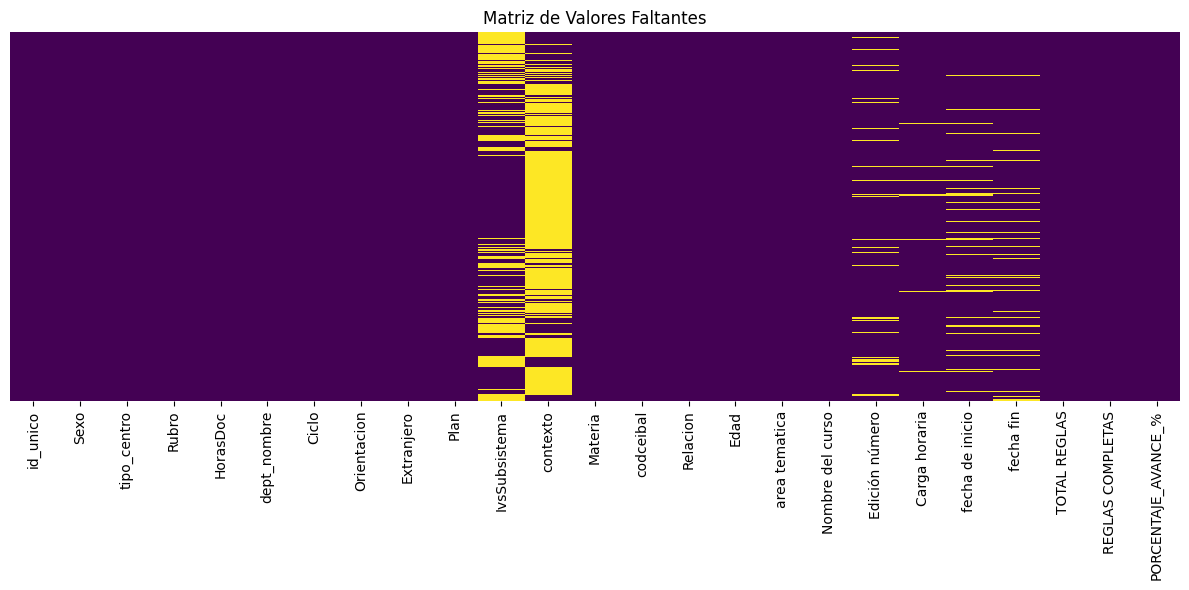

In [ ]:
# Visualizamos los valores faltantes
plt.figure(figsize=(12, 6))
sns.heatmap(csvFile_copia.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Matriz de Valores Faltantes')
plt.tight_layout()


In [ ]:
# Identificación y suma de datos nulos
csvFile_copia.isnull().sum()

,0
id_unico,0
Sexo,0
tipo_centro,0
Rubro,0
HorasDoc,0
dept_nombre,0
Ciclo,0
Orientacion,0
Extranjero,0
Plan,0


### **Observaciones:**
* Algunas columnas muestran datos nulos pero todas en un proporción igual o menor al 10% del dataset.

* Por la naturaleza del origen de los datos en algunos registros no corresponde que tome valor en la columna, el caso es el de IvsSubsitema y contexto, donde según un atributo del registro el dato puede tomar valor o no en esa variable.

* Para resolverlo se realiza un merge de las dos columnas dado que son de la misma naturaleza, conformando una nueva columna. Estas dos categorías refieren al quintil sociocultural.

* Edición número, se imputa el valor que corresponde a primera edición.

* Carga horaria, usaremos la moda para imputar los valores faltantes.

* Fecha de inicio y Fecha de fin, se eliminarán los registros que tengan valor nulo dado que corresponden a una porción pequeña y la eliminación es tolerable teniendo en cuenta la cantidad de registros del Data Set.

In [ ]:
# Function to extract the numerical quintil from a string
def extract_quintil(text):
    if pd.isna(text):
        return np.nan
    # Use regex to find one or more digits
    match = re.search(r'\d+', str(text))
    if match:
        return int(match.group(0))
    return np.nan

# Apply the function to extract quintils
csvFile_copia['IvsSubsistema_quintil'] = csvFile_copia['IvsSubsistema'].apply(extract_quintil)
csvFile_copia['contexto_quintil'] = csvFile_copia['contexto'].apply(extract_quintil)

# Combine the two quintil columns into a single 'Quintil socioeconomico' column
# Prioritize 'IvsSubsistema_quintil' if not NaN, otherwise use 'contexto_quintil'
csvFile_copia['Quintil socioeconomico'] = csvFile_copia['IvsSubsistema_quintil'].fillna(csvFile_copia['contexto_quintil'])

# Drop the intermediate columns
csvFile_copia = csvFile_copia.drop(columns=['IvsSubsistema_quintil', 'contexto_quintil'])

# Display the first few rows with the new column and its missing values
print(csvFile_copia[['IvsSubsistema', 'contexto', 'Quintil socioeconomico']].head())
print("\nMissing values in 'Quintil socioeconomico':")
print(csvFile_copia['Quintil socioeconomico'].isnull().sum())

  IvsSubsistema        contexto  Quintil socioeconomico
0           NaN  Sin clasificar                     NaN
1           NaN  Sin clasificar                     NaN
2           NaN  Sin clasificar                     NaN
3           NaN  Sin clasificar                     NaN
4           NaN  Sin clasificar                     NaN

Missing values in 'Quintil socioeconomico':
7031


In [ ]:
# Display unique values and their counts for the new 'Quintil socioeconomico' column
print("Unique values and counts for 'Quintil socioeconomico':")
print(csvFile_copia['Quintil socioeconomico'].value_counts(dropna=False))

Unique values and counts for 'Quintil socioeconomico':
Quintil socioeconomico
2.0    20785
1.0    19902
4.0    18217
3.0    17829
5.0    16001
NaN     7031
Name: count, dtype: int64


In [ ]:
print("\nMode of 'Quintil socioeconomico':")
print(csvFile_copia['Quintil socioeconomico'].mode())


Mode of 'Quintil socioeconomico':
0    2.0
Name: Quintil socioeconomico, dtype: float64


In [ ]:
# Imputación datos Quintil Socioeconómico
csvFile_copia['Quintil socioeconomico'].fillna(csvFile_copia['Quintil socioeconomico'].mode()[0], inplace=True)

# Verificar resultado
print("Valores únicos después de la imputación:")
print(csvFile_copia['Quintil socioeconomico'].value_counts())


Valores únicos después de la imputación:
Quintil socioeconomico
2.0    27816
1.0    19902
4.0    18217
3.0    17829
5.0    16001
Name: count, dtype: int64


In [ ]:
csvFile_copia = csvFile_copia.drop(['IvsSubsistema', 'contexto'], axis=1)

###Decidimos reemplazar los NaN de Quintil socioeconomico con la Moda, que es 2.0.

In [ ]:
# Imputación datos columna Edición número
csvFile_copia['Edición número'].fillna(1.0, inplace=True)

In [ ]:
csvFile_copia['Edición número'].isnull().sum()

np.int64(0)

###Decidimos reemplazar los NaN de Edición número con el valor mínimo que corresponde a 1er edición

In [ ]:
# Imputación datos Carga horaria
csvFile_copia['Carga horaria'].fillna(csvFile_copia['Carga horaria'].mode()[0], inplace=True)

# Verificar resultado
print("Valores únicos después de la imputación:")
print(csvFile_copia['Carga horaria'].value_counts())

Valores únicos después de la imputación:
Carga horaria
30     72668
35      9671
200     5295
50      3072
20      2940
150     2122
45      1240
120     1205
15       796
60       622
6o       134
Name: count, dtype: int64


In [ ]:
# Detectamos que un valor de carga horaría 6o no es un dato numérico entonces lo transformamos a numérico sustituyendolo por 60

# Replace '6o' with '60' in the 'Carga horaria' column
csvFile_copia['Carga horaria'] = csvFile_copia['Carga horaria'].replace('6o', '60')

# Convert 'Carga horaria' to numeric, coercing errors
csvFile_copia['Carga horaria'] = pd.to_numeric(csvFile_copia['Carga horaria'], errors='coerce')

# Fill NaN values with the mean before converting to integer
csvFile_copia['Carga horaria'] = csvFile_copia['Carga horaria'].fillna(csvFile_copia['Carga horaria'].mean())

# Convert 'Carga horaria' to integer
csvFile_copia['Carga horaria'] = csvFile_copia['Carga horaria'].astype(int)

# Display the data types to confirm the change
print(csvFile_copia.dtypes)

id_unico                           int64
Sexo                              object
tipo_centro                       object
Rubro                             object
HorasDoc                           int64
dept_nombre                       object
Ciclo                             object
Orientacion                       object
Extranjero                        object
Plan                              object
Materia                           object
codceibal                          int64
Relacion                          object
Edad                               int64
area tematica                     object
Nombre del curso                  object
Edición número                   float64
Carga horaria                      int64
fecha de inicio           datetime64[ns]
fecha fin                 datetime64[ns]
TOTAL REGLAS                       int64
REGLAS COMPLETAS                   int64
PORCENTAJE_AVANCE_%              float64
Quintil socioeconomico           float64
dtype: object


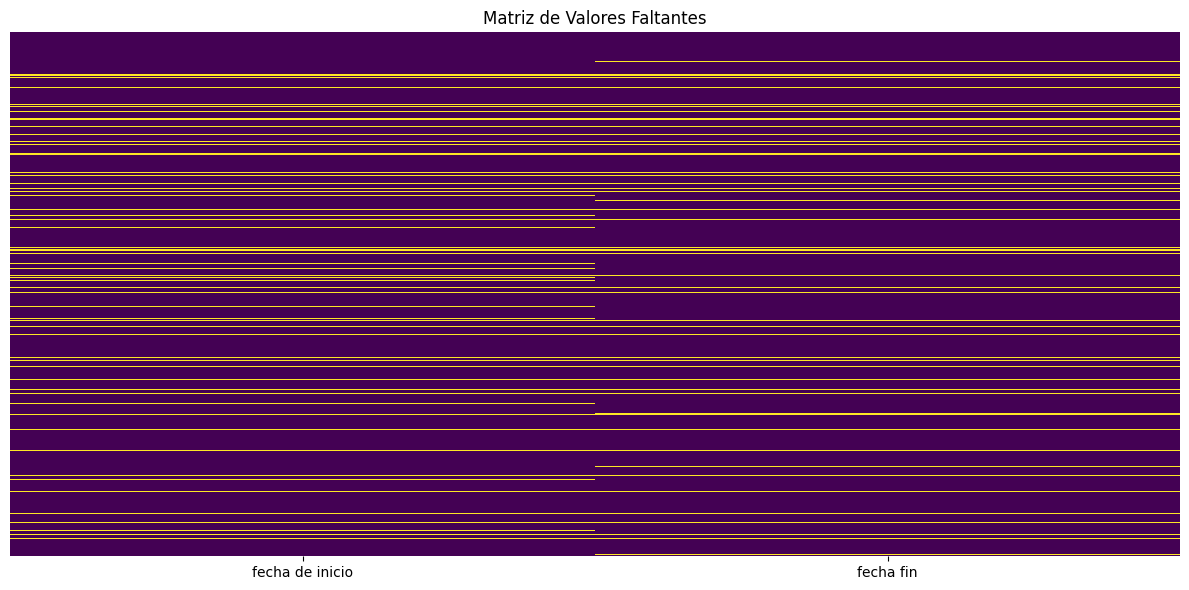

In [ ]:
# Visualizamos los valores faltantes para fecha de inicio y fecha de fin
plt.figure(figsize=(12, 6))
sns.heatmap(csvFile_copia[['fecha de inicio','fecha fin']].isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Matriz de Valores Faltantes')
plt.tight_layout()

### Dado que la mayoría de los registros que no tienen fecha de inicio tampoco tienen fecha de fin procedemos a eliminar los registros

In [ ]:
# Eliminar registros que tengan NaN en fecha de inicio O fecha de fin
csvFile_copia = csvFile_copia.dropna(subset=['fecha de inicio', 'fecha fin'])


In [ ]:
csvFile_copia[['fecha de inicio', 'fecha fin']].isnull().sum()

,0
fecha de inicio,0
fecha fin,0


In [ ]:
csvFile_copia.shape

(88590, 24)

In [ ]:
csvFile_copia.isnull().sum()

,0
id_unico,0
Sexo,0
tipo_centro,0
Rubro,0
HorasDoc,0
dept_nombre,0
Ciclo,0
Orientacion,0
Extranjero,0
Plan,0


## Tratamiento variables categóricas

In [ ]:
# Identify categorical columns
categorical_cols = csvFile_copia.select_dtypes(include=['object', 'category']).columns

# Veo los valores que hay de genero
print("Unique values for 'Sexo':")
print(pd.unique(csvFile_copia['Sexo']))

Unique values for 'Sexo':
['F' 'M']


In [ ]:
# Recategorización de Sexo a variable binaria

csvFile_copia['Sexo'] = csvFile_copia['Sexo'].map({'F': 1, 'M': 0})


In [ ]:
# Display unique values for the rest of the categorical columns
for col in categorical_cols:
    if col != 'Sexo': # Skip the 'Sexo' column as it was already displayed
        print(f"\nUnique values for '{col}':")
        print(pd.unique(csvFile_copia[col]))


Unique values for 'tipo_centro':
['Programas educativos' 'Escuela Pública' 'Inspección' 'Utu'
 'Jardín Público' 'Escuela Pública Especial' 'Liceo Público']

Unique values for 'Rubro':
['DGEIP' 'DGETP' 'DGES']

Unique values for 'dept_nombre':
['MONTEVIDEO' 'CANELONES' 'COLONIA' 'FLORIDA' 'PAYSANDU' 'RIVERA' 'SALTO'
 'SAN JOSE' 'SORIANO' 'ROCHA' 'TREINTA Y TRES' 'CERRO LARGO' 'MALDONADO'
 'DURAZNO' 'LAVALLEJA' 'ARTIGAS' 'FLORES' 'TACUAREMBO' 'RIO NEGRO'
 'Asunción']

Unique values for 'Ciclo':
['PRIMARIA' 'INICIAL' 'CICLO BASICO TECNOLOGICO'
 'EDUCACION BASICA INTEGRADA' 'EDUCACION MEDIA TECNOLOGICA'
 'BACHILLERATO TECNOLOGICO' 'FORMACION PROFESIONAL BASICA'
 'ARTICULACION EDUCACION MEDIA BASICA' 'DOCENCIA NO DIRECTA'
 'EDUCACION MEDIA TECNOLOGICA FINEST' 'BACHILLERATO TECNICO PROFESIONAL'
 'PRIMARIA ESPECIAL' 'BACHILLERATO PROFESIONAL'
 'EDUCACION MEDIA PROFESIONAL' 'CURSO TECNICO TERCIARIO'
 'INGENIERO TECNOLOGICO' 'HORAS EXTRACURRICULARES' 'TECNOLOGO'
 '3er. CICLO EBI' 'CICLO BASICO

### **Observaciones:**

* El data set presenta alta granularidad en las columnas Orientación y Materia se procede a recategorizar para aunar por áreas de conocimientos y estudio

In [ ]:
# Cuento cantidad de observaciones únicas por Orientación
print(csvFile_copia['Orientacion'].value_counts())

Orientacion
NO APLICA                           28928
SIN ESPECIFICAR                     26238
EDUCACION BASICA INTEGRADA           7422
DIV.HUMANISTICA                      2309
DIV.BIOLOGICA                        1850
                                    ...  
OPERADOR  INFORMATICO                   1
CARPINTERÍA INICIAL                     1
SISTEMAS DE IMPRESION                   1
MASAJES                                 1
ASISTENTES PRODUCCION C. DE OBRA        1
Name: count, Length: 211, dtype: int64


In [ ]:
# Recategorizar Orientación

# Definir el diccionario de recategorización
rama_conocimiento = {
    #  Ciencias Agrarias y Medio Ambiente
    'AGRARIO': 'Ciencias Agrarias y Medio Ambiente',
    'AGRARIO - RURAL': 'Ciencias Agrarias y Medio Ambiente',
    'FORESTAL': 'Ciencias Agrarias y Medio Ambiente',
    'AGROFORESTAL': 'Ciencias Agrarias y Medio Ambiente',
    'AGRICOLA GANADERO': 'Ciencias Agrarias y Medio Ambiente',
    'PRODUCCION VEGETAL': 'Ciencias Agrarias y Medio Ambiente',
    'PRODUCCIONES VEGETALES INTENSIVAS': 'Ciencias Agrarias y Medio Ambiente',
    'PRODUCCION LECHERA': 'Ciencias Agrarias y Medio Ambiente',
    'HORTIFRUTICULTURA': 'Ciencias Agrarias y Medio Ambiente',
    'PRODUCCION AGRICOLA GANADERA': 'Ciencias Agrarias y Medio Ambiente',
    'PRODUCCION AGROPECUARIA SUSTENTABLE': 'Ciencias Agrarias y Medio Ambiente',
    'MECANIZACION AGROINDUSTRIAL': 'Ciencias Agrarias y Medio Ambiente',
    'CONSERV ESPACIOS NAT Y AREAS VERDES': 'Ciencias Agrarias y Medio Ambiente',
    'CONSERV. GESTION AREAS NATUR': 'Ciencias Agrarias y Medio Ambiente',
    'GUARDAPARQUES': 'Ciencias Agrarias y Medio Ambiente',
    'VITIVINICULTURA': 'Ciencias Agrarias y Medio Ambiente',
    'FORESTAL - BINACIONAL': 'Ciencias Agrarias y Medio Ambiente',
    'AGRARIO BINACIONAL': 'Ciencias Agrarias y Medio Ambiente',
    'CBT INIC. A LA TECNOLOGIA RURAL': 'Ciencias Agrarias y Medio Ambiente',
    'AGRO FORESTAL': 'Ciencias Agrarias y Medio Ambiente',

    #  Ingeniería, Tecnología e Industria
    'MECANICA GENERAL': 'Ingeniería y Tecnología Industrial',
    'MECANICA AUTOMOTRIZ': 'Ingeniería y Tecnología Industrial',
    'ELECTROMECANICA': 'Ingeniería y Tecnología Industrial',
    'ELECTROMECANICA AUTOMOTRIZ': 'Ingeniería y Tecnología Industrial',
    'AUTOTRONICA': 'Ingeniería y Tecnología Industrial',
    'MANT. IND. ELECTROMECANICO ELECT.': 'Ingeniería y Tecnología Industrial',
    'MANTEN. IND.ELECTROMECANICO': 'Ingeniería y Tecnología Industrial',
    'MECANICA INDUSTRIAL': 'Ingeniería y Tecnología Industrial',
    'AUTOMATIZACION INDUSTRIAL': 'Ingeniería y Tecnología Industrial',
    'SOLDADURA INDUSTRIAL': 'Ingeniería y Tecnología Industrial',
    'SOLDADURA': 'Ingeniería y Tecnología Industrial',
    'MAQUINARIA PESADA': 'Ingeniería y Tecnología Industrial',
    'CHAPA Y PINTURA': 'Ingeniería y Tecnología Industrial',
    'CARROCERIA Y ESTETICA DEL AUTOMOVIL': 'Ingeniería y Tecnología Industrial',
    'REP. VEHICULOS Y MANT. MOTORES HIBR': 'Ingeniería y Tecnología Industrial',
    'REP VEHI ELECT Y MANT SIST HIBRID': 'Ingeniería y Tecnología Industrial',
    'MAQUINISTA NAVAL': 'Ingeniería y Tecnología Industrial',
    'MECANICA NAVAL': 'Ingeniería y Tecnología Industrial',
    'CONSTRUCCION DE EMBARCACIONES': 'Ingeniería y Tecnología Industrial',
    'AERONAUTICA': 'Ingeniería y Tecnología Industrial',
    'AERONAUTICA SIST. MOTOPROPULSORES': 'Ingeniería y Tecnología Industrial',
    'AERONAUTICA SISTEMAS DE AERONAVES': 'Ingeniería y Tecnología Industrial',
    'AERONAUTICA AVIONICA': 'Ingeniería y Tecnología Industrial',
    'INDUSTRIAL': 'Ingeniería y Tecnología Industrial',
    'QUIMICA INDUSTRIAL': 'Ingeniería y Tecnología Industrial',
    'ENERGIAS RENOVABLES': 'Ingeniería y Tecnología Industrial',
    'ELECTRONICA': 'Ingeniería y Tecnología Industrial',
    'ELECTROTECNIA': 'Ingeniería y Tecnología Industrial',
    'ELECTROTECNIA BASICA': 'Ingeniería y Tecnología Industrial',
    'ELECTROTECNIA Y ENERG.ALTERNATIVAS': 'Ingeniería y Tecnología Industrial',
    'SISTEMAS MECANICOS AUTOMATIZADOS': 'Ingeniería y Tecnología Industrial',
    'REFRIGERACION': 'Ingeniería y Tecnología Industrial',
    'SISTEMAS DE CLIMATIZACION': 'Ingeniería y Tecnología Industrial',
    'INSTALACIONES ELECTRICAS': 'Ingeniería y Tecnología Industrial',
    'INSTALACIONES SANITARIAS': 'Ingeniería y Tecnología Industrial',
    'OP. MANT. INST. ELECTRICAS BT - MT': 'Ingeniería y Tecnología Industrial',
    'OP.MANT. INSTALACIONES TRANSMISION': 'Ingeniería y Tecnología Industrial',
    'CONSTRUCCION': 'Ingeniería y Tecnología Industrial',
    'CONSTRUCCION INTEGRADA': 'Ingeniería y Tecnología Industrial',
    'EDIFICACIONES - OBRA CIVIL': 'Ingeniería y Tecnología Industrial',
    'CONST. VIVIENDAS Y ABERTURAS': 'Ingeniería y Tecnología Industrial',
    'INFOGRAFIA Y TECN. LA CONSTRUCCION': 'Ingeniería y Tecnología Industrial',
    'MUEBLES POR DISEÑO': 'Ingeniería y Tecnología Industrial',
    'CONSTRUCCION BASICA DE MUEBLES': 'Ingeniería y Tecnología Industrial',
    'CONST. MUEBLES POR DISEÑO': 'Ingeniería y Tecnología Industrial',
    'CARPINTERIA': 'Ingeniería y Tecnología Industrial',
    'CARPINTERIA DE RIBERA': 'Ingeniería y Tecnología Industrial',
    'CARPINTERÍA INICIAL': 'Ingeniería y Tecnología Industrial',
    'PROG. CASAVALLE CARPINTERIA': 'Ingeniería y Tecnología Industrial',
    'TALLA EN MADERA': 'Ingeniería y Tecnología Industrial',
    'SISTEMAS DE IMPRESION': 'Ingeniería y Tecnología Industrial',
    'NAUTICA Y PESCA': 'Ingeniería y Tecnología Industrial',

    #  Informática y Tecnología de la Información
    'INFORMATICA': 'Tecnologías de la Información',
    'INFORMATICA BILINGÜE - WEB': 'Tecnologías de la Información',
    'INFORMATICA ENFASIS DESARROLLO WEB': 'Tecnologías de la Información',
    'INFORMATICA E. DESARROLLO Y SOPORTE': 'Tecnologías de la Información',
    'OPERADOR INFORMATICO BASICO': 'Tecnologías de la Información',
    'OPERADOR INFORMATICO AVANZADO': 'Tecnologías de la Información',
    'OPERADOR  INFORMATICO': 'Tecnologías de la Información',
    'SOPORTE TECNICO INFORMATICO': 'Tecnologías de la Información',
    'REDES Y TELECOMUNICACIONES': 'Tecnologías de la Información',
    'TELECOMUNICACIONES': 'Tecnologías de la Información',
    'IT Y REDES': 'Tecnologías de la Información',
    'REDES Y SOFTWARE': 'Tecnologías de la Información',
    'CIBERSEGURIDAD': 'Tecnologías de la Información',
    'DESARROLLO DE APLICACIONES WEB': 'Tecnologías de la Información',
    'PROGRAMACION Y VIDEOJUEGOS': 'Tecnologías de la Información',
    'ROBOTICA': 'Tecnologías de la Información',
    'ROBOTICA Y AUTOMATISMOS': 'Tecnologías de la Información',
    'ROBOTICA Y TELECOMUNICACIONES': 'Tecnologías de la Información',
    'TECNOLOGIAS DE LA INFORMACION': 'Tecnologías de la Información',
    'TECNOLOGIAS DE LA INFORMACION - BIL': 'Tecnologías de la Información',
    'FIBRA OPTICA': 'Tecnologías de la Información',
    'TECNOLOGO EN INFORMATICA': 'Tecnologías de la Información',

    #  Ciencias, Biología y Química
    'DIV.BIOLOGICA': 'Ciencias Naturales',
    'DIV.CIENTIFICA': 'Ciencias Naturales',
    'BIOLOGICO': 'Ciencias Naturales',
    'BIOTECNOLOGIA': 'Ciencias Naturales',
    'CIENCIAS NATURALES Y TECNOLOGIA': 'Ciencias Naturales',
    'CIENCIAS Y TECNOLOGIA DE LABORAT.': 'Ciencias Naturales',
    'ASISTENTES DE LABORATORIO P.I.': 'Ciencias Naturales',
    'ASISTENTE LABORATORIO INFORMATICA': 'Ciencias Naturales',

    #  Ciencias Sociales, Humanidades y Comunicación
    'DIV.HUMANISTICA': 'Ciencias Sociales y Humanidades',
    'HUMANISTICO': 'Ciencias Sociales y Humanidades',
    'EDUCADORES': 'Ciencias Sociales y Humanidades',
    'FUNCIONES TECNICO PEDAGOGICAS': 'Ciencias Sociales y Humanidades',
    'FUNCIONES TECNICO ADMINISTRATIVAS': 'Ciencias Sociales y Humanidades',
    'PROYECTOS  PEDAGOGICOS': 'Ciencias Sociales y Humanidades',
    'COM. SOCIAL OP. PUBLICIDAD': 'Ciencias Sociales y Humanidades',
    'COM. SOCIAL OP. RR.PP.': 'Ciencias Sociales y Humanidades',
    'COM. SOCIAL OP. PRENSA': 'Ciencias Sociales y Humanidades',
    'COM. SOCIAL OP.TELEVISION': 'Ciencias Sociales y Humanidades',
    'COM. SOCIAL OP. RADIODIFUSIO': 'Ciencias Sociales y Humanidades',
    'TECNICO EN COMUNICACION SOCIAL': 'Ciencias Sociales y Humanidades',
    'MEDIOS AUDIOVISUALES Y COMUNICACION': 'Ciencias Sociales y Humanidades',
    'SECRETARIADO BILINGÜE - INGLES': 'Ciencias Sociales y Humanidades',
    'SECRETARIADO BILINGÜE BINACIONAL': 'Ciencias Sociales y Humanidades',
    'GESTION HUMANA': 'Ciencias Sociales y Humanidades',

    #  Administración, Comercio y Turismo
    'ADMINISTRACION': 'Administración y Negocios',
    'ADMINISTRACION REFORMULADO': 'Administración y Negocios',
    'GESTION Y ADMINISTRACION': 'Administración y Negocios',
    'GESTION EMPRESAS TURISTICAS': 'Administración y Negocios',
    'GESTION DE ALOJAMIENTO': 'Administración y Negocios',
    'GESTION DE VINOS Y ACEITE DE OLIVA': 'Administración y Negocios',
    'MARKETING': 'Administración y Negocios',
    'LOGISTICA': 'Administración y Negocios',
    'LOGISTICA - BINACIONAL': 'Administración y Negocios',
    'COMERCIO Y LOGISTICA': 'Administración y Negocios',
    'CORREDOR DE SEGUROS': 'Administración y Negocios',
    'OPERADOR INMOBILIARIO': 'Administración y Negocios',
    'REMATADOR': 'Administración y Negocios',
    'ORGANIZACION DE EVENTOS': 'Administración y Negocios',
    'D. ITINERARIO TURISTICO SOSTENIBLE': 'Administración y Negocios',
    'TURISMO': 'Administración y Negocios',
    'TURISMO, HOSPITALIDAD Y OCIO': 'Administración y Negocios',
    'ALOJAMIENTO': 'Administración y Negocios',
    'ALOJAMIENTO Y SERV. TURISITICOS': 'Administración y Negocios',
    'ALOJAMIENTO Y SERV. TUR. BINACIONAL': 'Administración y Negocios',

    #  Artes, Diseño y Expresión
    'DIV.ARTE Y EXPRESION': 'Arte y Diseño',
    'DISEÑO': 'Arte y Diseño',
    'DISEÑO GRAFICO EN COM. VISUAL': 'Arte y Diseño',
    'DISEÑO Y ESPACIOS SUSTENTABLES': 'Arte y Diseño',
    'AUDIOVISUAL': 'Arte y Diseño',
    'AUDIOVISUALES': 'Arte y Diseño',
    'AUDIOVISUAL PROD, DIR ART Y GUION': 'Arte y Diseño',
    'ARTES GRAFICAS': 'Arte y Diseño',
    'DIBUJO Y PINTURA': 'Arte y Diseño',
    'ESCULTURA': 'Arte y Diseño',
    'CERAMICA': 'Arte y Diseño',
    'JOYERIA': 'Arte y Diseño',
    'SERIGRAFIA': 'Arte y Diseño',
    'COMPOSICION Y PRODUCCION MUSICAL': 'Arte y Diseño',
    'MUSICA': 'Arte y Diseño',
    'ACTIVIDADES MUSICALES': 'Arte y Diseño',
    'TECNICAS CREATIVAS': 'Arte y Diseño',

    #  Bienestar, Salud y Deporte
    'DEPORTE Y RECREACION': 'Salud, Deporte y Bienestar',
    'DEPORTE, ED. FISICA Y RECREACION': 'Salud, Deporte y Bienestar',
    'EDUCACION FISICA': 'Salud, Deporte y Bienestar',
    'GESTION DEPORTIVA': 'Salud, Deporte y Bienestar',
    'REHABILITACION FISICA Y MASOTERAPIA': 'Salud, Deporte y Bienestar',
    'ASIST. COMUNITARIA Y PROMO. SALUD': 'Salud, Deporte y Bienestar',
    'BIENESTAR Y SALUD': 'Salud, Deporte y Bienestar',
    'MASAJES': 'Salud, Deporte y Bienestar',
    'REACONDICIONAMIENTO FISICO DEP.': 'Salud, Deporte y Bienestar',
    'PREVENCIONISTA': 'Salud, Deporte y Bienestar',
    'PREVENCIONISTA  SEMIPRESENCIAL': 'Salud, Deporte y Bienestar',
    'SEGURIDAD VIAL': 'Salud, Deporte y Bienestar',
    'PEDICURIA': 'Salud, Deporte y Bienestar',
    'ESTETICA INTEGRAL': 'Salud, Deporte y Bienestar',
    'ESTETICA CAPILAR': 'Salud, Deporte y Bienestar',
    'ESTETICA DE SALON': 'Salud, Deporte y Bienestar',
    'BELLEZA INTEGRAL ENFASIS CAPILAR': 'Salud, Deporte y Bienestar',
    'OPTICO': 'Salud, Deporte y Bienestar',
    'ESTILISMO ARTISTICO': 'Salud, Deporte y Bienestar',

    #  Gastronomía, Alimentación y Servicios
    'ALIMENTACION': 'Gastronomía y Servicios',
    'COCINA': 'Gastronomía y Servicios',
    'GASTRONOMIA': 'Gastronomía y Servicios',
    'GASTRONOMIA - BINACIONAL': 'Gastronomía y Servicios',
    'SERVICIOS GASTRONOMICOS': 'Gastronomía y Servicios',
    'PASTELERIA': 'Gastronomía y Servicios',
    'GESTION DE VINOS Y ACEITE DE OLIVA': 'Gastronomía y Servicios',

    #  Programas transversales / indefinidos
    'NO APLICA': 'General / Transversal',
    'SIN ESPECIFICAR': 'General / Transversal',
    'REDESCUBRIR - F.P.B. M1-M2': 'General / Transversal',
    'PROGRAMA RUMBO': 'General / Transversal',
    'UAL - PLAN DE INTEGRACION': 'General / Transversal',
    'E.B.I. RURAL EXTENDIDO': 'General / Transversal',
    'E.B.I. ALTERNANCIA': 'General / Transversal',
    'EDUCACION BASICA INTEGRADA': 'General / Transversal',
    'DES. INTEGRAL DEL ALUMNO': 'General / Transversal',
    'EQUIPOS MULTIDISCIPLINARIOS': 'General / Transversal',
    'REFERENTES Y COORDINADORES': 'General / Transversal',
    'ESP.CURR. OPT. GENERAL': 'General / Transversal',
    'ESP. CURR. OPT. PROFUNDIZACION': 'General / Transversal',
    'D. I. T. S. DE LA NATURALEZA': 'General / Transversal',
    'ASISTENTES PRODUCCION C. DE OBRA': 'General / Transversal',
    'ASISTENTE DE DIRECCION': 'General / Transversal',
    'FUNCIONES TECNICO ADMINISTRATIVAS': 'General / Transversal'
}


# Crear una nueva columna con la recategorización
csvFile_copia['Rama_Docente'] = csvFile_copia['Orientacion'].map(rama_conocimiento)


print(csvFile_copia['Rama_Docente'].value_counts())

Rama_Docente
General / Transversal                 65715
Tecnologías de la Información          4044
Ciencias Naturales                     3940
Ciencias Sociales y Humanidades        3231
Administración y Negocios              2954
Salud, Deporte y Bienestar             2332
Ingeniería y Tecnología Industrial     2219
Gastronomía y Servicios                1370
Arte y Diseño                          1107
Ciencias Agrarias y Medio Ambiente     1011
Name: count, dtype: int64


In [ ]:
# Cuento cantidad de observaciones únicas por Materia
print(csvFile_copia['Materia'].value_counts())

Materia
NO APLICA                       27121
MATEMATICA                       3754
INGLES                           3111
HISTORIA                         3101
BIOLOGIA                         2618
                                ...  
PRODUCCION CARPINTERIA              1
GESTION (ACTIVIDADES)               1
HISTORIA DE LA RECREACION           1
TUTORIA DE PROYECTOS I              1
ASISTENTE TELECOMUNICACIONES        1
Name: count, Length: 740, dtype: int64


In [ ]:
# Función para normalizar las categorias

def clasificar_materia(texto):
    t = str(texto).upper()

    #  Ciencias Naturales
    if any(k in t for k in ['BIOLOGIA', 'QUIMICA', 'FISICA', 'GEOLOGIA', 'ECOLOGIA', 'AMBIENTE', 'BIOTECNOLOGIA']):
        return 'Ciencias Naturales'

    #  Matemática y Estadística
    elif any(k in t for k in ['MATEMATICA', 'ESTADISTICA', 'LOGICA', 'CUANTITATIV', 'NUMERIC']):
        return 'Matemática y Estadística'

    #  Tecnología e Informática
    elif any(k in t for k in ['INFORMATICA', 'PROGRAMACION', 'SOFTWARE', 'REDES', 'DATOS', 'SISTEMAS OPERATIVOS',
                              'COMPUTACION', 'TECNOLOGIA', 'ROBOTICA', 'CIBERSEGURIDAD']):
        return 'Tecnología e Informática'

    #  Ingeniería y Tecnología Industrial
    elif any(k in t for k in ['ELECTROTECNIA', 'ELECTRONICA', 'ELECTROMECANICA', 'CONSTRUCCION', 'MECANICA',
                              'PRODUCCION', 'AGROPECUARIA', 'INDUSTRIAL', 'MAQUINARIA', 'ENERGIA', 'PROCESOS']):
        return 'Ingeniería y Tecnología Industrial'

    # Lengua, Literatura y Comunicación
    elif any(k in t for k in ['IDIOMA', 'LENGUA', 'LITERATURA', 'COMUNICACION', 'ESPAÑOL', 'PORTUGUES', 'INGLES',
                              'ITALIANO', 'FRANCES', 'LINGÜISTICA', 'ORAL', 'ESCRITA']):
        return 'Lengua y Comunicación'

    #  Ciencias Sociales y Humanidades
    elif any(k in t for k in ['HISTORIA', 'GEOGRAFIA', 'SOCIOLOGIA', 'FILOSOFIA', 'PSICOLOGIA',
                              'CIUDADANIA', 'DERECHO', 'ECONOMIA', 'POLITICA', 'SOCIAL']):
        return 'Ciencias Sociales y Humanidades'

    #  Arte y Diseño
    elif any(k in t for k in ['ARTE', 'DISEÑO', 'DIBUJO', 'MUSICA', 'TEATRO', 'PLASTICA', 'EXPRESION', 'GRAFICA']):
        return 'Arte y Diseño'

    #  Administración, Economía y Gestión
    elif any(k in t for k in ['ADMINISTRACION', 'GESTION', 'CONTABILIDAD', 'FINANZAS', 'EMPRESARIAL', 'MARKETING',
                              'LOGISTICA', 'EMPRENDEDURISMO', 'PUBLICA']):
        return 'Administración y Economía'

    #  Gastronomía, Turismo y Servicios
    elif any(k in t for k in ['COCINA', 'GASTRONOMIA', 'SERVICIO', 'TURISMO', 'HOTELERIA', 'ENOLOGIA']):
        return 'Gastronomía y Servicios'

    #  Salud, Deporte y Bienestar
    elif any(k in t for k in ['EDUCACION FISICA', 'DEPORTE', 'RECREACION', 'SALUD', 'ANATOMIA',
                              'HIGIENE', 'MASAJE', 'NUTRICION', 'BIOMECANICA']):
        return 'Salud y Deporte'

    #  Educación y Formación General
    elif any(k in t for k in ['EDUCACION', 'FORMACION', 'METODOLOGIA', 'PEDAGOG', 'DOCENCIA']):
        return 'Educación'

    #  Si no coincide con nada
    else:
        return 'Otras / No Clasificada'


#  Aplicar la función al DataFrame
csvFile_copia['Materia_Docente'] = csvFile_copia['Materia'].apply(clasificar_materia)

#  Revisar los resultados
print(csvFile_copia['Materia_Docente'].value_counts())


Materia_Docente
Otras / No Clasificada                34004
Tecnología e Informática              12735
Lengua y Comunicación                 10913
Ciencias Naturales                    10817
Ciencias Sociales y Humanidades       10441
Matemática y Estadística               4331
Arte y Diseño                          2509
Ingeniería y Tecnología Industrial     1148
Salud y Deporte                         805
Administración y Economía               664
Gastronomía y Servicios                 122
Educación                               101
Name: count, dtype: int64


In [ ]:
csvFile_copia = csvFile_copia.drop(columns=['Orientacion', 'Materia'])

In [ ]:
csvFile_copia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88590 entries, 0 to 99764
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_unico                88590 non-null  int64         
 1   Sexo                    88590 non-null  int64         
 2   tipo_centro             88590 non-null  object        
 3   Rubro                   88590 non-null  object        
 4   HorasDoc                88590 non-null  int64         
 5   dept_nombre             88590 non-null  object        
 6   Ciclo                   88590 non-null  object        
 7   Extranjero              88590 non-null  object        
 8   Plan                    88590 non-null  object        
 9   codceibal               88590 non-null  int64         
 10  Relacion                88590 non-null  object        
 11  Edad                    88590 non-null  int64         
 12  area tematica           88590 non-null  object     

## **Síntesis**

* Se utilizaron estrategias de imputación de datos nulos en casi todos los casos con el uso de la moda dada la naturaleza discreta de las variables

* Se recategorizaron columnas para bajar la granularidad de las mismas llevando estas agrupaciones por áreas de asignaturas y ramas de estudio

* Una gran porción de los registros, en particular en las columnas que refieren a las asignaturas y orientacion de los cursos que dan los docentes, aparecen con la categoría NO APLICA.

* El data set contiene a razón de 90 mil registros con valor para análisis




# **Visualización y análisis de datos**


### **Gráficos de BoxPlot e Histogramas**

---



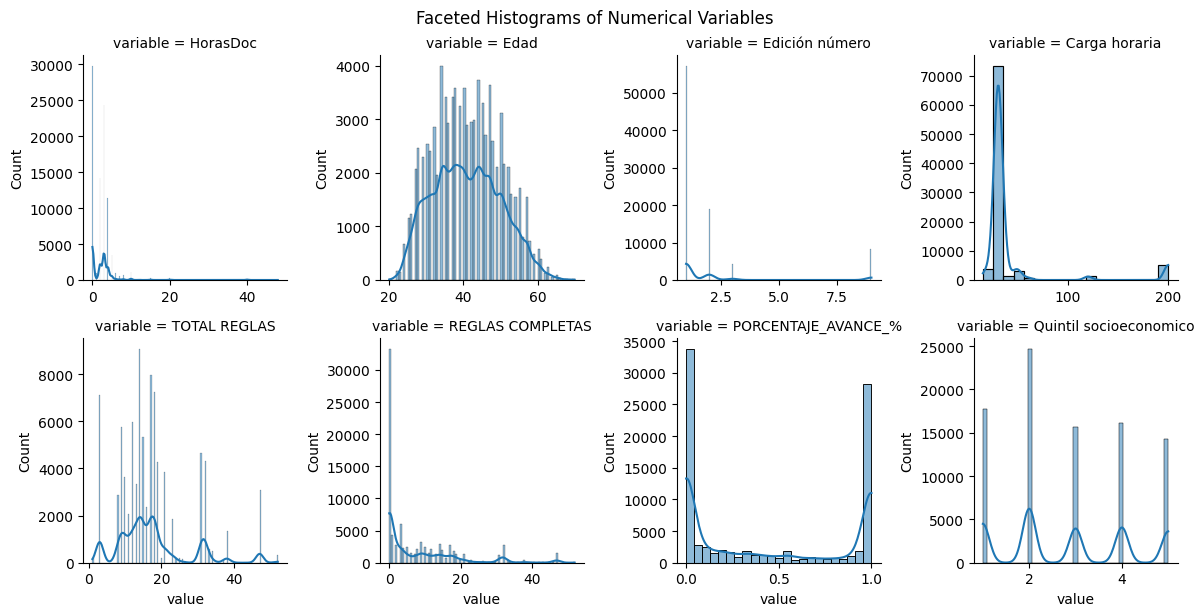

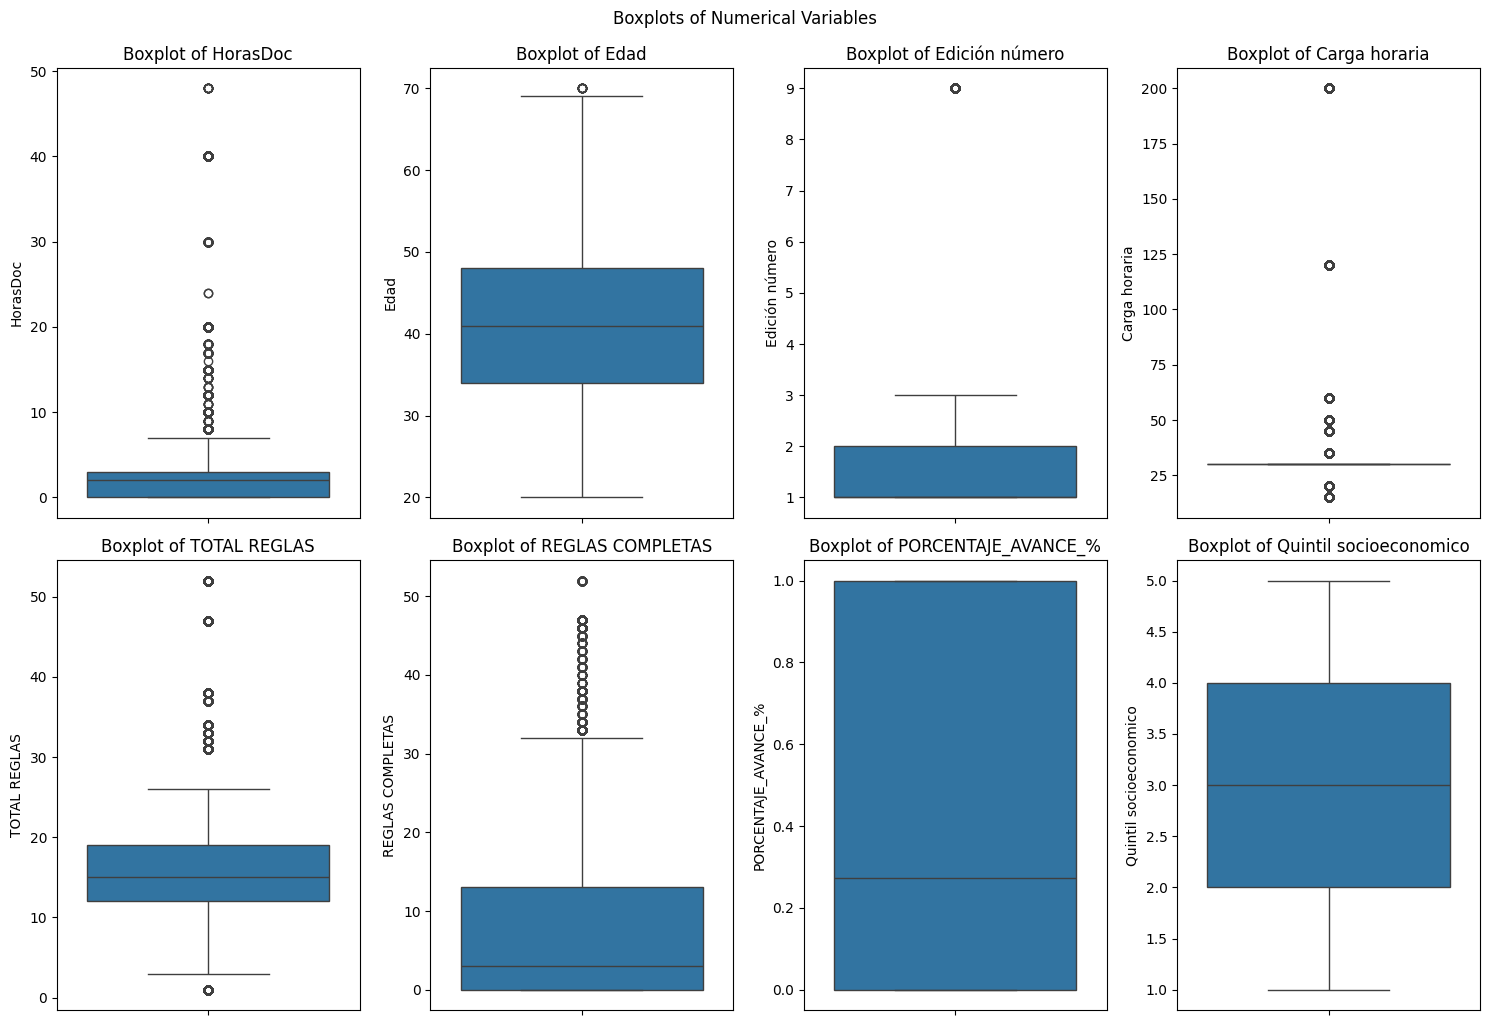

In [ ]:
# Select numerical columns for plotting
numerical_cols = csvFile_copia.select_dtypes(include=np.number).columns

cols_excluir = ['id_unico', 'Sexo', 'codceibal']
numerical_cols = [col for col in numerical_cols if col not in cols_excluir]

# Create faceted histograms
g = sns.FacetGrid(csvFile_copia.melt(value_vars=numerical_cols), col="variable", col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, "value", kde=True)
plt.suptitle('Faceted Histograms of Numerical Variables', y=1.02)
plt.show()

# Create grid of boxplots
num_cols = len(numerical_cols)
n_cols = 4
n_rows = (num_cols + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=csvFile_copia[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.suptitle('Boxplots of Numerical Variables', y=1.02)
plt.show()

### **Observaciones:**

* HorasDoc: La mayoría de los docentes registra pocas horas dedicadas. Existen valores atípicos con más de 40 horas, pero son casos excepcionales.

* Edad: La distribución es casi normal, centrada entre 35 y 45 años, lo que indica una población adulta con experiencia.

* Edición número: Predomina la edición 1, con pocas repeticiones de curso, lo que sugiere cohortes nuevas.

* Total de reglas: La mayoría de los cursos tienen entre 10 y 20 reglas, aunque algunos alcanzan más de 50, mostrando diferencias en el nivel de actividad.

* Reglas completas: La mayoría de los docentes completa pocas reglas, y existen varios docentes con 0, lo que refleja posibles abandonos o dificultades.

* Porcentaje de avance: Se observa una distribución bimodal, con muchos docentes que no avanzan y otro grupo que completa casi todo el curso, evidenciando dos comportamientos opuestos de participación.

#### **Conclusión:**
El grupo presenta una alta variabilidad en el esfuerzo y el progreso. La mayoría dedica poco tiempo y avanza poco, mientras que una minoría logra completar el curso con alto nivel de compromiso.

### **Análisis de normalidad**

**Analizamos si edad se distribuye de manera normal**

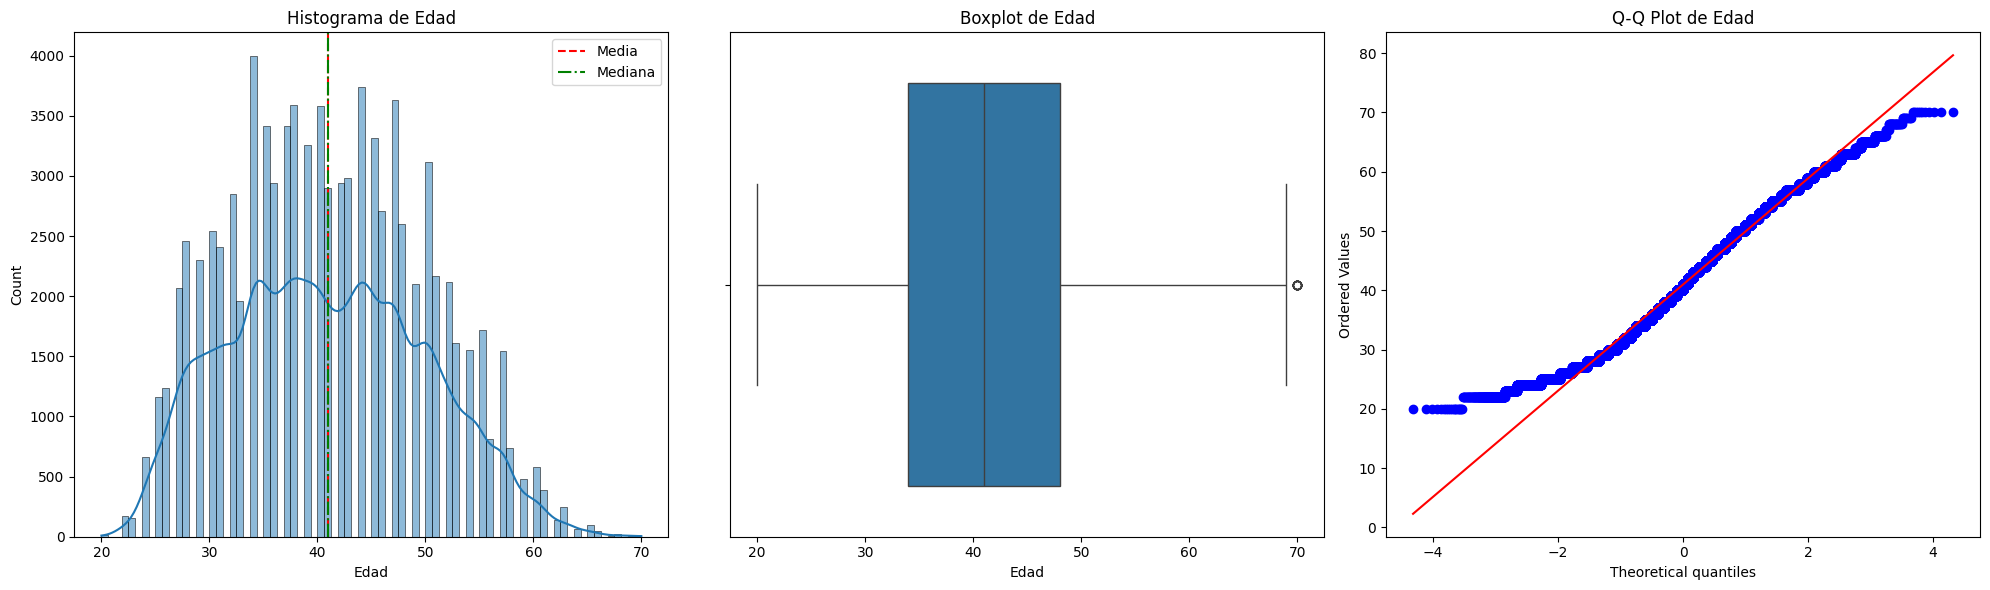


Estadísticas resumidas para Edad:
count    88590.000000
mean        40.970143
std          9.021103
min         20.000000
25%         34.000000
50%         41.000000
75%         48.000000
max         70.000000
Name: Edad, dtype: float64

Asimetría: 0.1760
Curtosis: -0.6915

Prueba de normalidad Shapiro-Wilk:
Estadístico: 0.9854, p-valor: 7.9386e-64
Los datos no siguen una distribución normal (rechaza H0)


In [ ]:
## visualizacion normal Edad de los docentes

def visualizar_distribucion(datos, columna):
    """Visualiza la distribución de una variable con histograma, boxplot y QQ plot."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Histograma con curva de densidad
    sns.histplot(datos[columna], kde=True, ax=axes[0])
    axes[0].axvline(datos[columna].mean(), color='red', linestyle='--', label='Media')
    axes[0].axvline(datos[columna].median(), color='green', linestyle='-.', label='Mediana')
    axes[0].set_title(f'Histograma de {columna}')
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=datos[columna], ax=axes[1])
    axes[1].set_title(f'Boxplot de {columna}')

    # QQ plot
    stats.probplot(datos[columna], plot=axes[2])
    axes[2].set_title(f'Q-Q Plot de {columna}')

    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas resumidas
    print(f"\nEstadísticas resumidas para {columna}:")
    print(datos[columna].describe())

    # Mostrar medidas de forma
    print(f"\nAsimetría: {datos[columna].skew():.4f}")
    print(f"Curtosis: {datos[columna].kurtosis():.4f}")

    # Prueba de normalidad
    stat, p_valor = stats.shapiro(datos[columna])
    print(f"\nPrueba de normalidad Shapiro-Wilk:")
    print(f"Estadístico: {stat:.4f}, p-valor: {p_valor:.4e}")
    if p_valor < 0.05:
        print("Los datos no siguen una distribución normal (rechaza H0)")
    else:
        print("No hay evidencia para rechazar la normalidad de los datos")

# Ejemplo de uso para cada columna
visualizar_distribucion(csvFile_copia, 'Edad')

### **Observaciones:**

* La edad de los docentes no sigue una distribución normal

Prueba de normalidad Shapiro-Wilk:<br>
Estadístico: 0.9859, p-valor: 4.1280e-65<br>
Los datos no siguen una distribución normal (rechaza H0)
<br>
<br>

### **Barplots y Frecuencias**

---


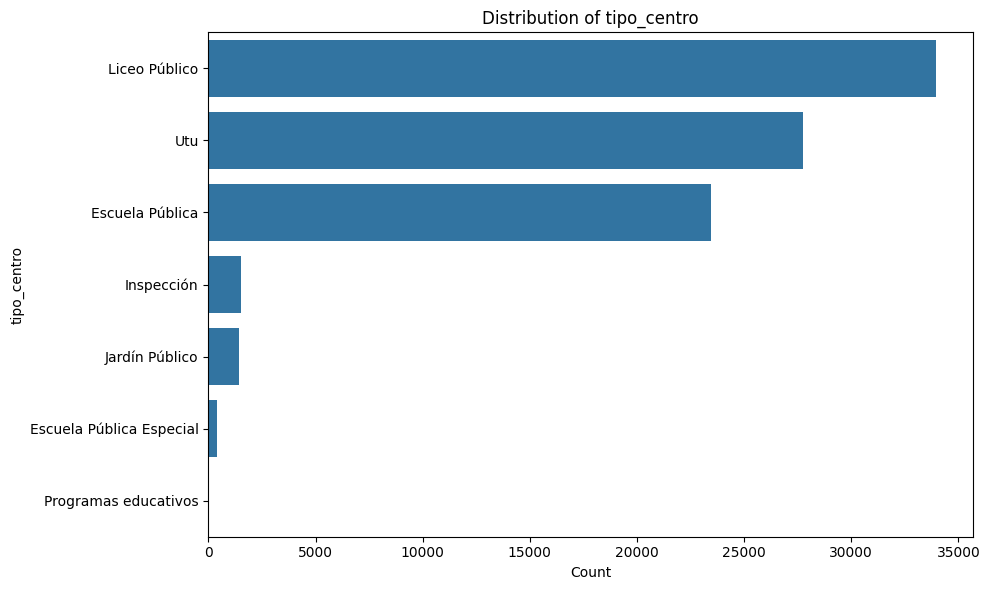

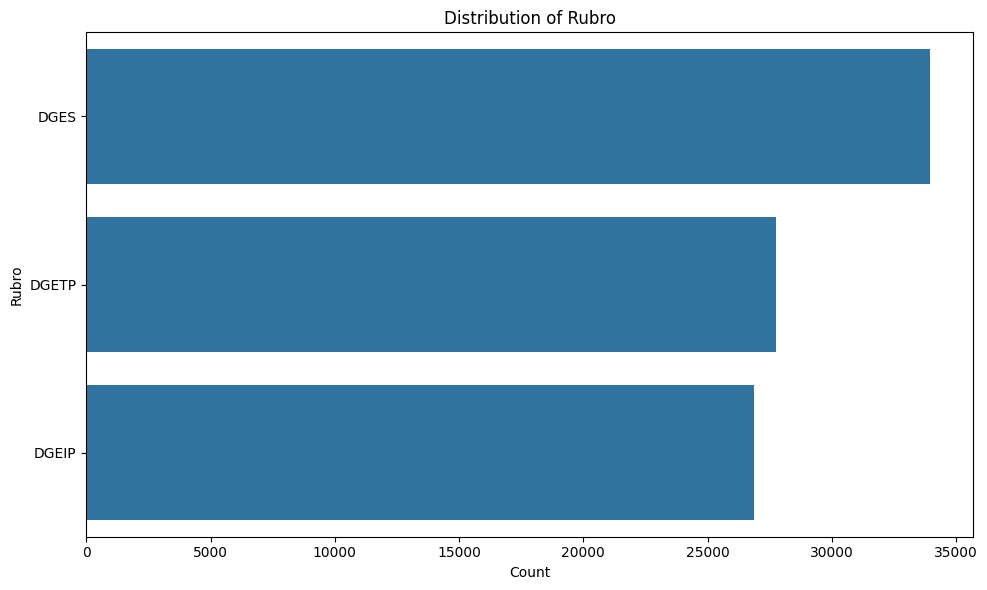

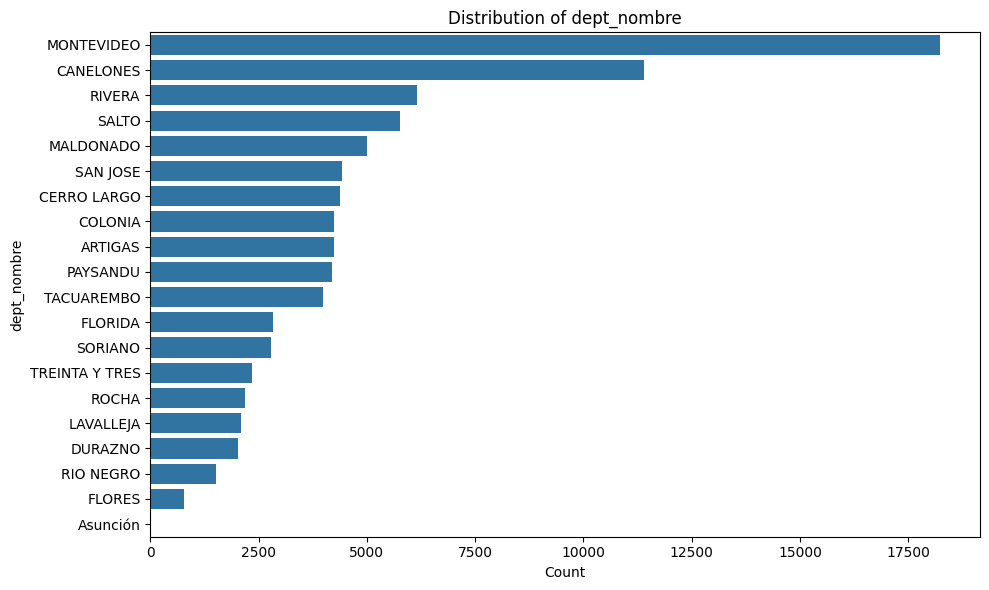

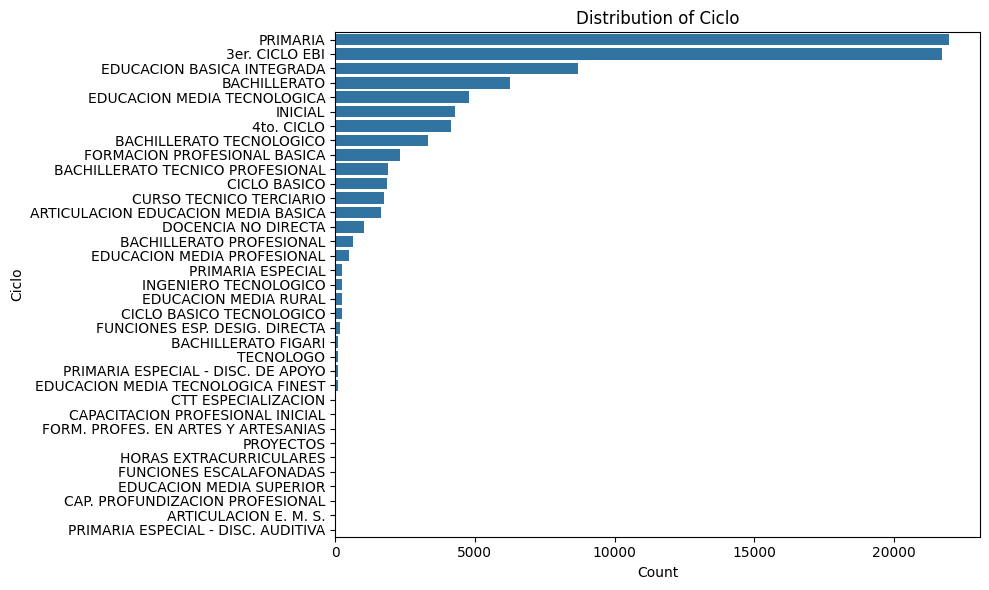

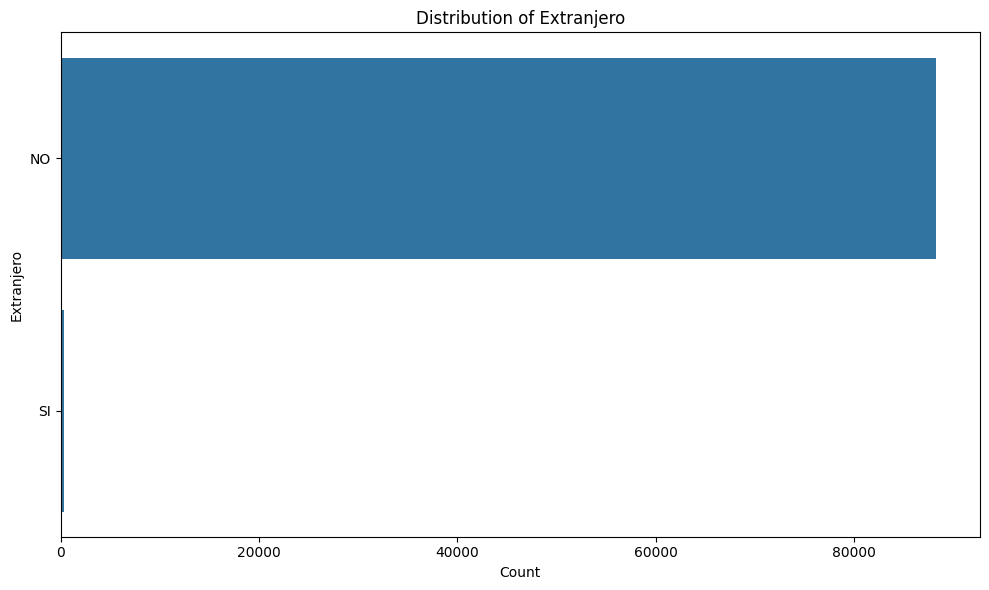

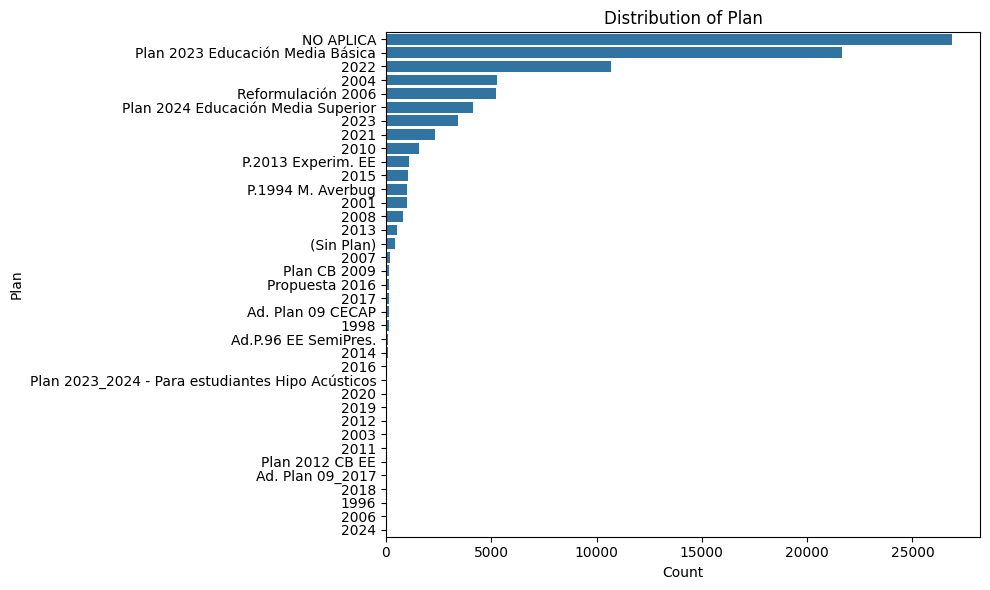

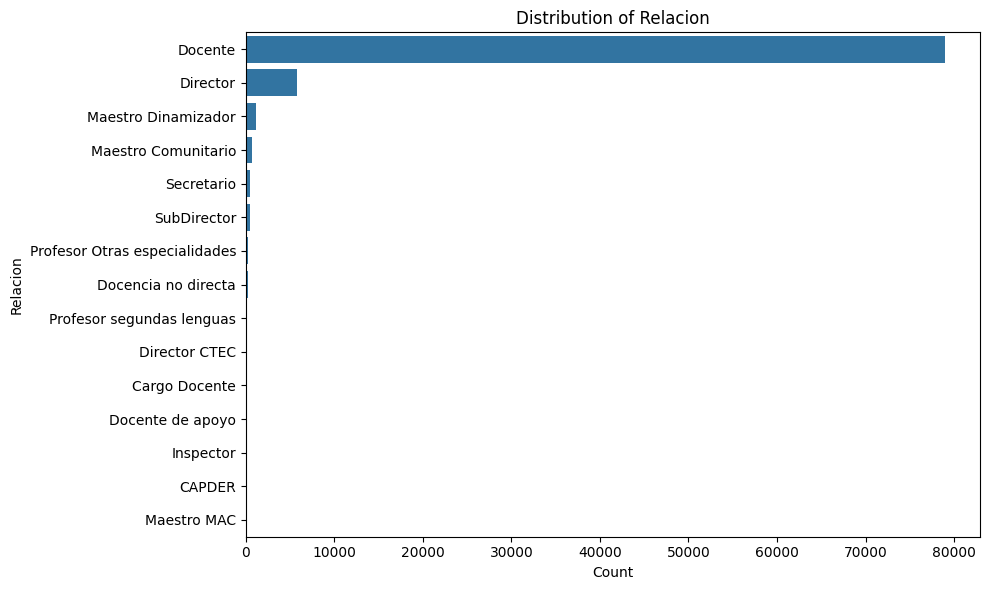

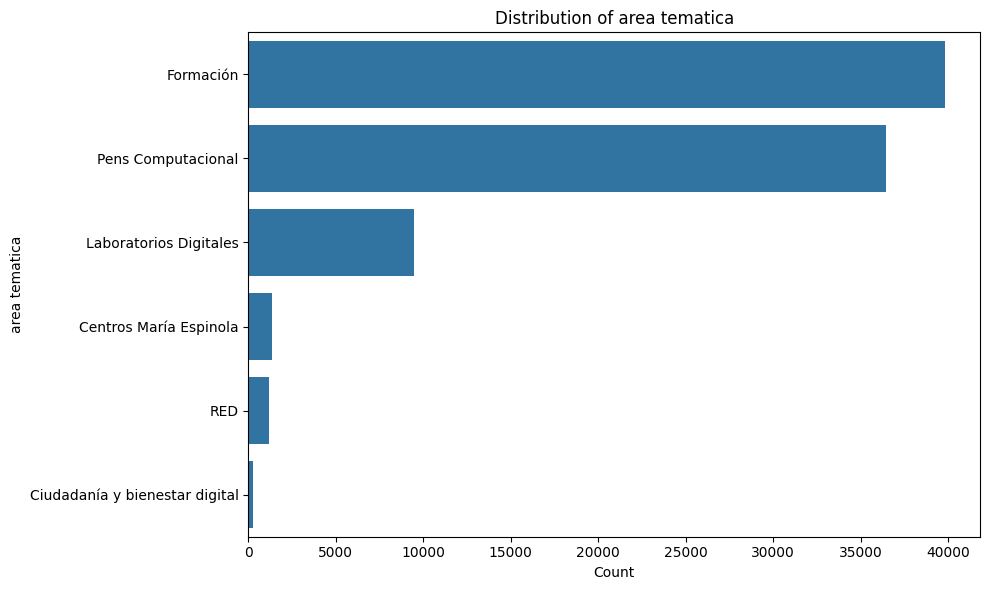

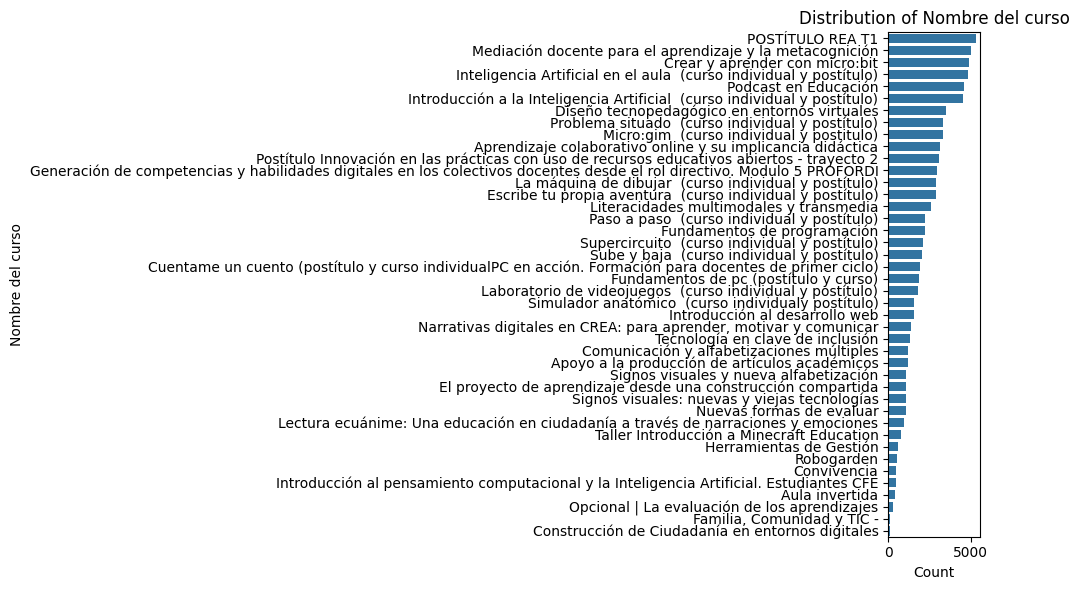

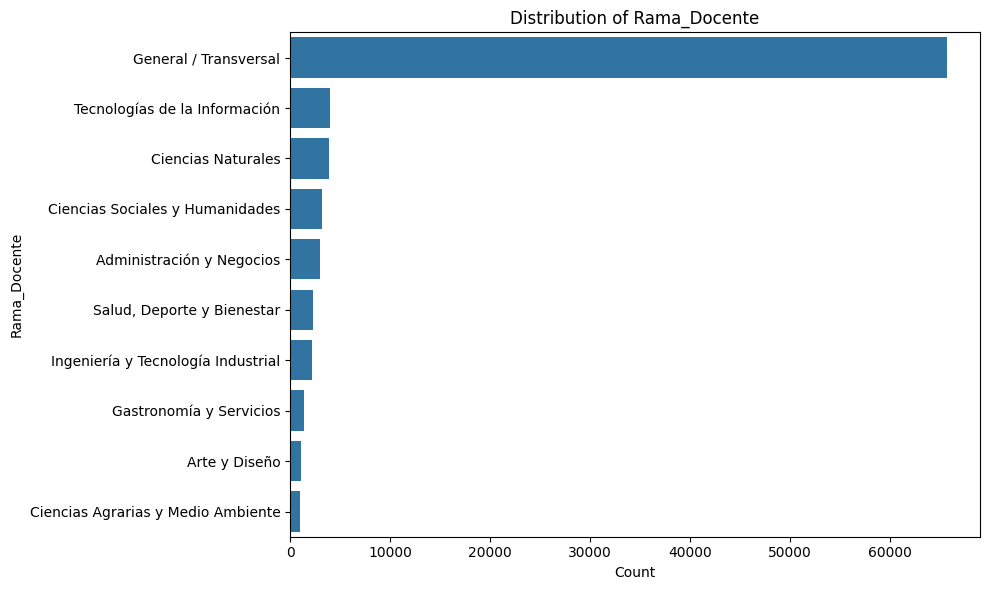

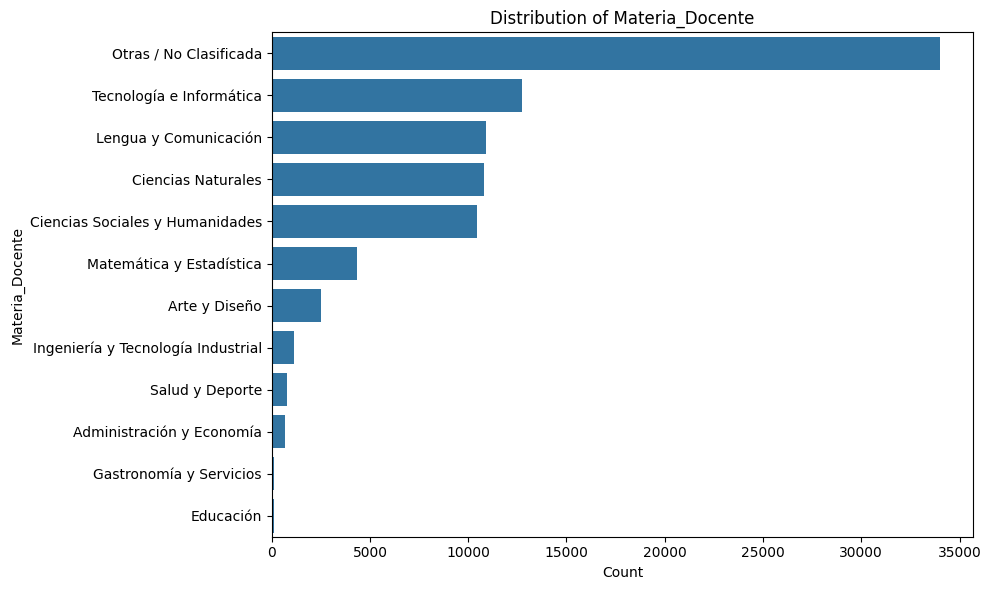

In [ ]:
# Identify categorical columns
categorical_cols = csvFile_copia.select_dtypes(include=['object', 'category']).columns

# Create bar plots for each categorical column
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=csvFile_copia, y=col, order=csvFile_copia[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
# Get the top courses by counting the occurrences of each course name
top_courses = csvFile_copia['Nombre del curso'].value_counts().head(10) # Get the top 10

# Display the top courses
print("Top 10 Cursos Más Populares:")
print(top_courses)

Top 10 Cursos Más Populares:
Nombre del curso
POSTÍTULO REA T1                                                             5295
Mediación docente para el aprendizaje y la metacognición                     4991
Crear y aprender con micro:bit                                               4905
Inteligencia Artificial en el aula  (curso individual y postítulo)           4818
Podcast en Educación                                                         4589
Introducción a la Inteligencia Artificial  (curso individual y postítulo)    4516
Diseño tecnopedagógico en entornos virtuales                                 3482
Problema situado  (curso individual y postítulo)                             3350
Micro:gim  (curso individual y postitulo)                                    3350
Aprendizaje colaborativo online y su implicancia didáctica                   3143
Name: count, dtype: int64


## Observaciones

**Gráficos de docentes:**

* tipo_centro: La mayoría de los docentes provienen de "Liceo Público", seguido por "UTU" y "Escuela Pública". Hay una menor representación de otros tipos de centro como "Inspección", "Jardín Público" y "Escuela Pública Especial".

* Rubro: El rubro "DGES" tiene la mayor cantidad de docentes, pero se observa una distrubición bastante similar a nivel de subsistema.

* dept_nombre: La mayoría de los docentes se encuentran en "MONTEVIDEO", seguido por "CANELONES". Los demás departamentos tienen una cantidad significativamente menor de docentes.

* Ciclo: "PRIMARIA" es el ciclo con más docentes, seguido por "3er. Ciclo EBI" (Ciclo básico). Los otros ciclos tienen una menor representación, y hay una alta granularidad en esta variable, sobre todo porque conviven múltiples ciclos en Secundaria y UTU.

* Extranjero: La gran mayoría de los docentes no son extranjeros ("NO").

* Plan: "NO APLICA" es las categoría más frecuente, lo que corresponde a docentes que no están asociados a un plan específico o esta información no está registrada, como se da en el caso de Primaria. En segundo lugar se encuentra el último plan implementado para ciclo básico "Plan 2025 EMB". Hay una alta variedad de otros planes, al igual que con el Ciclo.

* Relacion: La mayoría de los registros corresponden a docentes, pero se observan algunas otras categorías con pocos registros como "Director", "Maestro dinamizador", "Maestro comunitario", etc.

* Rama_Docente: "General / Transversal" es la rama docente más común, lo que concuerda con la alta frecuencia de "NO APLICA" y "SIN ESPECIFICAR" en la columna original "Orientacion". Le siguen "Tecnologías de la Información" y "Ciencias Naturales".

* Materia_Docente: "Otras / No Clasificada" es la categoría más frecuente, reflejando nuevamente la granularidad de la columna original "Materia". Le siguen "Tecnología e Informática" y "Lengua y Comunicación".

**Gráficos de los Cursos:**

* En relación al área temática de los cursos que toman los docentes, "Formación" y "Pens Computacional" son las áreas donde se observa una mayor cantidad de docentes inscriptos.

* En cuanto a la distrubución de inscriptos por curso, “POSTÍTULO REA T1” es el curso con mayor número de registros, superando los 5,000 participantes (aprox.), seguido por otros como
“Mediación docente para el aprendizaje y la metacognición”,
“Crear y aprender con micro:bit”,
“Inteligencia Artificial en el aula”, e
“Podcast en Educación”. Por otro lado, la mayoría de los cursos tienen una frecuencia mucho menor, lo que indica una distribución muy desigual (sesgada a la derecha).

En conjunto, el panorama muestra un perfil docente diverso pero con fuerte presencia de secundaria pública, y una oferta formativa con alta concentración de demanda en ciertos cursos clave, principalmente vinculados a innovación y tecnología educativa.

## **Análisis multivariado**



#### **Matriz de Correlación**

---



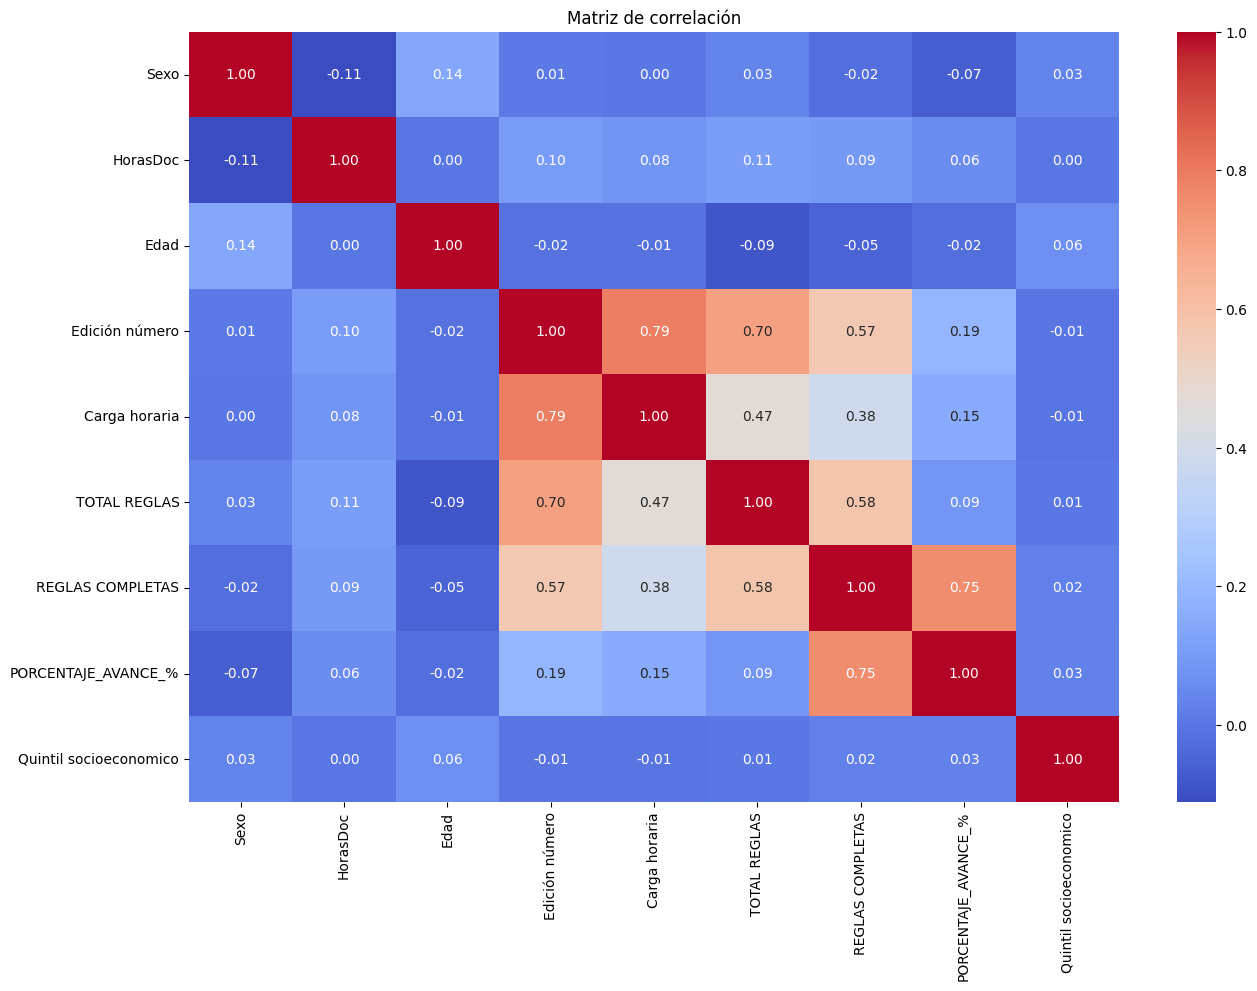

In [ ]:
# Select numerical columns
numerical_cols = csvFile_copia.select_dtypes(include=np.number).columns

# Columns to exclude from the correlation (but keep in the dataset)
exclude = ['id_unico', 'codceibal', 'ID']

# Filter the columns for correlation
corr_cols = [c for c in numerical_cols if c not in exclude]

# Compute correlation on the filtered set
correlation_matrix = csvFile_copia[corr_cols].corr()

# Plot
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de correlación')
plt.show()


###**Observaciones sobre la matriz de correlación**

**Correlaciones fuertes:**

* Existe una correlación alta entre Edición número y Carga horaria (0.79), indicando que las ediciones más recientes tienden a tener más carga.

* Edición número, Total de reglas y Reglas completas presentan correlaciones positivas (0.70 y 0.57), lo que sugiere coherencia entre cantidad de reglas y progreso.

* Reglas completas y Porcentaje de avance tienen una correlación muy alta (0.75), lo cual es lógico, ya que ambas miden el nivel de cumplimiento del curso.

**Correlaciones moderadas:**

* Carga horaria y Total de reglas (0.47) muestran que a mayor carga, suelen asignarse más reglas.

**Correlaciones débiles o nulas:**

* Variables como Sexo, Edad y Quintil socioeconómico tienen correlaciones muy bajas con el rendimiento o avance, indicando poca influencia en el progreso académico.

* HorasDoc también presenta correlaciones bajas, sugiriendo la carga horaria de actividades docentes del docente no explica el progreso en los cursos.

###**Conclusión:**
* En base a la evidencia podemos suponer que el avance de los docentes depende principalmente de la estructura del curso (cantidad de reglas, edición y carga horaria), más que de factores personales o contextuales. Dejando entrever que la estructura interna del curso es importante.

* En ese sentido una primera hipótesis es que dividir el curso en una cantidad mayor de reglas podría aumentar la participación con impacto en el exito del docente respecto de la aprobación del curso


### **Resultados y Discusión**

El análisis estadístico del conjunto de datos muestra que la mayoría de los docentes registra una baja dedicación horaria de horas de clase, con pocos casos que superan las 40 horas. La variable Edad presenta una distribución casi normal concentrada entre los 35 y 45 años, lo que refleja una población adulta con experiencia profesional. En cuanto a la Edición del curso, predomina la primera edición, lo que sugiere cohortes nuevas y escasa repetición de cursadas. Las variables Total de reglas y Reglas completas evidencian una amplia dispersión: la mayoría de los cursos contiene entre 10 y 20 reglas, pero los niveles de completitud son bajos, con una proporción importante de docentes que no completan ninguna regla. Esta tendencia se confirma en la variable Porcentaje de avance, que presenta una distribución bimodal con dos grupos marcados: quienes no avanzan y quienes completan casi todo el curso.

El análisis de las variables relacionadas con el perfil docente permite complementar estos hallazgos. La mayoría de los docentes proviene de Liceos Públicos y del rubro DGES, aunque se observa una distribución relativamente equilibrada entre subsistemas. Geográficamente, Montevideo y Canelones concentran la mayor proporción de docentes, con menor representación en el resto de los departamentos. El ciclo predominante es Primaria, seguido por el 3er Ciclo EBI, y la variable Plan presenta una alta heterogeneidad, destacándose la categoría “NO APLICA” y el “Plan 2025 EMB”. La relación funcional es mayoritariamente docente, con pocos casos de cargos directivos o especializados. En cuanto a la especialización, las ramas más frecuentes son “General / Transversal”, “Tecnologías de la Información” y “Ciencias Naturales”, mientras que las materias con mayor representación son “Otras / No Clasificada”, “Tecnología e Informática” y “Lengua y Comunicación”. En conjunto, estos resultados reflejan un perfil docente diverso, con fuerte presencia del ámbito público y una marcada heterogeneidad disciplinar.

En relación con los cursos, las áreas temáticas de “Formación” y “Pensamiento Computacional” concentran la mayor cantidad de inscriptos. La distribución de participantes por curso es altamente desigual: “POSTÍTULO REA T1” supera los 5.000 inscriptos, seguido por “Mediación docente para el aprendizaje y la metacognición”, “Crear y aprender con micro:bit”, “Inteligencia Artificial en el aula” y “Podcast en Educación”. La mayoría de los cursos presenta una menor participación, lo que evidencia una concentración de la demanda en programas específicos, principalmente asociados a innovación y tecnología educativa.

La matriz de correlación refuerza estos hallazgos. Se observa una fuerte relación positiva entre las variables Edición número, Carga horaria, Total de reglas y Reglas completas, lo que sugiere que la estructura del curso incide directamente en el nivel de avance. En particular, la alta correlación entre Reglas completas y Porcentaje de avance (0.75) confirma que el progreso depende del cumplimiento efectivo de las actividades. En cambio, variables como Sexo, Edad y Quintil socioeconómico muestran correlaciones débiles, lo que indica que los factores personales o contextuales no explican el rendimiento en forma significativa.

En conjunto, los resultados permiten inferir que la estructura interna del curso (cantidad de reglas, carga horaria y diseño de la edición) es el principal determinante del avance docente. Además, el perfil del cuerpo docente y la concentración temática de los cursos sugieren que las estrategias de formación continua deberían considerar la diversidad de contextos institucionales y la alta demanda en áreas tecnológicas. Una posible hipótesis derivada es que dividir el curso en una mayor cantidad de reglas o unidades pequeñas podría fomentar una participación más sostenida y mejorar la tasa de finalización, al reducir la percepción de carga y favorecer el seguimiento progresivo del aprendizaje.


## Próximos pasos

* Organizar el conjunto de datos de manera que permita representar el recorrido formativo completo de cada docente, con el objetivo de identificar los caminos de aprendizaje más exitosos y utilizarlos como base para el desarrollo de un sistema de recomendación inteligente.


* Construcción de modelo predictivo: Diseñar, entrenar y evaluar modelos de machine learning capaces de predecir la completitud del curso a partir de variables relacionadas con las características del docente, la estructura del curso y las métricas de participación. Este modelo permitirá anticipar el nivel de avance y detectar factores clave de éxito.


* Segmentación docente: Aplicar técnicas de clustering y análisis de conglomerados para identificar perfiles docentes diferenciados según características demográficas, profesionales y comportamentales. Esta segmentación permitirá comprender mejor las necesidades formativas y personalizar las estrategias de aprendizaje.


* Sistema de recomendación: Desarrollar e implementar un sistema de recomendación personalizado que sugiera cursos óptimos para cada perfil docente, basándose en los patrones de éxito identificados, las predicciones del modelo y la similitud entre trayectorias de aprendizaje.




# Sistema de recomendación

En primer lugar, observamos que para realizar un sistema de recomendación es necesario realizar algunas transformaciones en la forma del dataset. Aplicamos una estrategia de Feature Engineering para cosolidar todas las características de los cursos y los docentes en filas unicas.

In [ ]:
#observamos la estructura del dataset original
csvFile_copia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88590 entries, 0 to 99764
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_unico                88590 non-null  int64         
 1   Sexo                    88590 non-null  int64         
 2   tipo_centro             88590 non-null  object        
 3   Rubro                   88590 non-null  object        
 4   HorasDoc                88590 non-null  int64         
 5   dept_nombre             88590 non-null  object        
 6   Ciclo                   88590 non-null  object        
 7   Extranjero              88590 non-null  object        
 8   Plan                    88590 non-null  object        
 9   codceibal               88590 non-null  int64         
 10  Relacion                88590 non-null  object        
 11  Edad                    88590 non-null  int64         
 12  area tematica           88590 non-null  object     

In [ ]:
csvFile_copia.head()

,id_unico,Sexo,tipo_centro,Rubro,HorasDoc,dept_nombre,Ciclo,Extranjero,Plan,codceibal,...,Edición número,Carga horaria,fecha de inicio,fecha fin,TOTAL REGLAS,REGLAS COMPLETAS,PORCENTAJE_AVANCE_%,Quintil socioeconomico,Rama_Docente,Materia_Docente
0,1040904,1,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO,NO APLICA,1101261,...,1.0,30,2024-05-10,2024-06-14,3,0,0.0,2.0,General / Transversal,Otras / No Clasificada
1,1040904,1,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO,NO APLICA,1101261,...,1.0,30,2024-05-10,2024-06-14,3,0,0.0,2.0,General / Transversal,Otras / No Clasificada
2,1040904,1,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO,NO APLICA,1101261,...,1.0,30,2024-06-17,2024-07-23,14,0,0.0,2.0,General / Transversal,Otras / No Clasificada
3,1040904,1,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO,NO APLICA,1101261,...,1.0,30,2024-07-24,2024-09-01,12,0,0.0,2.0,General / Transversal,Otras / No Clasificada
4,1040904,1,Programas educativos,DGEIP,0,MONTEVIDEO,PRIMARIA,NO,NO APLICA,1101261,...,1.0,30,2024-07-24,2024-09-01,12,0,0.0,2.0,General / Transversal,Otras / No Clasificada


In [ ]:
# Observamos los estadísticos de % de avance
print("Valores únicos de PORCENTAJE_AVANCE_%:")
print(csvFile_copia["PORCENTAJE_AVANCE_%"].unique()[:50])

print("\nResumen estadístico:")
print(csvFile_copia["PORCENTAJE_AVANCE_%"].describe())

Valores únicos de PORCENTAJE_AVANCE_%:
[0.         1.         0.66666667 0.4        0.68421053 0.25806452
 0.28571429 0.26666667 0.88888889 0.44680851 0.3125     0.08333333
 0.875      0.9        0.21052632 0.6        0.45454545 0.1
 0.17647059 0.25       0.20588235 0.58823529 0.5        0.78571429
 0.02631579 0.42857143 0.92857143 0.94117647 0.21428571 0.3
 0.16666667 0.47058824 0.33333333 0.85714286 0.13333333 0.125
 0.8        0.18181818 0.11538462 0.34615385 0.07692308 0.18421053
 0.23809524 0.54166667 0.65625    0.15384615 0.4516129  0.46808511
 0.07142857 0.53333333]

Resumen estadístico:
count    88590.000000
mean         0.443415
std          0.443880
min          0.000000
25%          0.000000
50%          0.272727
75%          1.000000
max          1.000000
Name: PORCENTAJE_AVANCE_%, dtype: float64


## Ingeniería de Features



### 1. Limpieza y normalización
- Convierte fechas y porcentajes a tipos numéricos válidos.
- Asegura que todos los campos críticos puedan ser usados en cálculos posteriores.

### 2. Consolidación por docente–curso
- Agrupa todas las filas repetidas por `id_unico` + `Nombre del curso`.
- Genera un único registro por curso cursado con:
  - promedio de avance,
  - características demográficas del docente,
  - metadata del curso (área temática, reglas, carga horaria, etc).

### 3. Construcción de user features
- Para cada docente se crea un vector de features que incluye:
  - sexo, edad, quintil,
  - tipo de centro, rubro, departamento, ciclo,
  - planes, rama docente, materias.
- Cada atributo se convierte en un token categórico usando el formato `colname:valor`.

### 4. Construcción de item features
- Para cada curso se construye un vector con:
  - área temática,
  - edición,
  - carga horaria,
  - duración en días,
  - ratio de completitud (proxy de dificultad).
- Todos los atributos se transforman en tokens categóricos como  
  `area:Matemática`, `Duracion:45d`, `ComplecionRatio:0.83`.

### 5. Ingeniería de “Success Paths”
- Detecta cursos que los docentes completan realmente (según un umbral configurable).
- Ordena los cursos completados por cada docente en forma cronológica.
- Extrae transiciones reales A→B entre cursos.
- Calcula `p(B|A)`: probabilidad de que un curso B siga a un curso A.
- Filtra transiciones fuertes según soporte mínimo.
- Construye secuencias pedagógicas reales basadas en progresiones observadas.

### 6. Features nuevos para ITEMS
- A cada curso B se le agregan tokens `path_from::<A>` para cada predecesor fuerte A.
- Se agrega también un atributo adicional como conteo: `num_paths_from:n`.
- Permite que el modelo aprenda prerrequisitos y progresiones educativas reales.

### 7. Features nuevos para USERS
- Para cada docente se agregan features indicando cursos completados:  
  `user_completed::<A>`.
- Se restringen a cursos relevantes para evitar ruido.
- Se agrega un feature numérico adicional:  
  `user_num_completed:n`, que indica la cantidad total de cursos completados.
- Permite capturar la historia educativa real del docente en el embedding del modelo.

### 8. Validación de densidad
- Cuenta cuántos cursos y usuarios recibieron features nuevos.
- Verifica que la ingeniería de progresión generó señal útil y no ruido.

### Resultado final
Este pipeline genera un dataset enriquecido con:
- perfil pedagógico del usuario,
- características educativas del curso,
- patrones reales de progresión A→B,
- historial de completitud del docente.

Esto permite entrenar un modelo LightFM/SVD++ capaz de:
- recomendar caminos educativos coherentes,
- priorizar cursos con mayor probabilidad de completitud,
- maximizar precisión y relevancia,
- reducir cold start utilizando progresiones pedagógicas reales.


In [ ]:
## INGENIERIA DE FEATURES

#import pandas as pd
#import numpy as np
#from datetime import datetime

# -------------------------------------------------------------------
# 0) Sanitizar tipos básicos que usaremos (por si vienen como object)
# -------------------------------------------------------------------
csvFile_copia["fecha de inicio"] = pd.to_datetime(csvFile_copia["fecha de inicio"], errors="coerce")
csvFile_copia["fecha fin"]       = pd.to_datetime(csvFile_copia["fecha fin"], errors="coerce")
csvFile_copia["PORCENTAJE_AVANCE_%"] = pd.to_numeric(csvFile_copia["PORCENTAJE_AVANCE_%"], errors="coerce")

# -------------------------------------------------------------------
# 1) Agrupar por docente–curso (tu bloque original, intacto)
# -------------------------------------------------------------------
df_grouped = (
    csvFile_copia.groupby(["id_unico", "Nombre del curso"], as_index=False)
      .agg({
          "PORCENTAJE_AVANCE_%": "mean",
          "Sexo": "first",
          "tipo_centro": lambda x: list(set(x)),
          "Rubro": lambda x: list(set(x)),
          "dept_nombre": lambda x: list(set(x)),
          "Ciclo": lambda x: list(set(x)),
          "Extranjero": "first",
          "Plan": lambda x: list(set(x)),
          "Relacion": "first",
          "Edad": "mean",
          "Quintil socioeconomico": "mean",
          "Rama_Docente": lambda x: list(set(x)),
          "Materia_Docente": lambda x: list(set(x)),
          "area tematica": "first",
          "Edición número": "mean",
          "Carga horaria": "mean",
          "TOTAL REGLAS": "mean",
          "REGLAS COMPLETAS": "mean",
          "fecha de inicio": "first",
          "fecha fin": "first"
      })
)

# -------------------------------------------------------------------
# 2) USER FEATURES (tu bloque original + builder)
# -------------------------------------------------------------------
user_features_df = (
    df_grouped.groupby("id_unico")
      .agg({
          "Sexo": "first",
          "Edad": "mean",
          "tipo_centro": "first",
          "Rubro": "first",
          "dept_nombre": lambda x: list(set(sum(x, []))),
          "Ciclo": lambda x: list(set(sum(x, []))),
          "Extranjero": "first",
          "Plan": lambda x: list(set(sum(x, []))),
          "Relacion": "first",
          "Quintil socioeconomico": "mean",
          "Rama_Docente": lambda x: list(set(sum(x, []))),
          "Materia_Docente": lambda x: list(set(sum(x, [])))
      })
      .reset_index()
)

def build_user_feature_list(row):
    feats = [
        f"Sexo:{row['Sexo']}",
        f"Extranjero:{row['Extranjero']}",
        f"Relacion:{row['Relacion']}",
        f"Edad_{int(row['Edad']//10*10)}s",
        f"Quintil:{int(row['Quintil socioeconomico']) if not pd.isna(row['Quintil socioeconomico']) else 'NA'}",
    ]
    for colname in ["tipo_centro", "Rubro", "dept_nombre", "Ciclo", "Plan", "Rama_Docente", "Materia_Docente"]:
        values = row[colname]
        if isinstance(values, list):
            feats.extend([f"{colname}:{v}" for v in values])
        else:
            feats.append(f"{colname}:{values}")
    return feats

user_features_df["user_features"] = user_features_df.apply(build_user_feature_list, axis=1)

# -------------------------------------------------------------------
# 3) ITEM FEATURES (tu bloque original + builder)
# -------------------------------------------------------------------
item_features_df = (
    df_grouped.groupby("Nombre del curso")
      .agg({
          "area tematica": "first",
          "Edición número": "mean",
          "Carga horaria": "mean",
          "TOTAL REGLAS": "mean",
          "REGLAS COMPLETAS": "mean",
          "fecha de inicio": "first",
          "fecha fin": "first"
      })
      .reset_index()
)

def build_item_feature_list(row):
    feats = [
        f"area:{row['area tematica']}",
        f"Edicion:{int(row['Edición número']) if not pd.isna(row['Edición número']) else 0}",
        f"CargaHoraria:{int(row['Carga horaria']) if not pd.isna(row['Carga horaria']) else 0}",
    ]
    # Derivar duración del curso
    if isinstance(row["fecha de inicio"], pd.Timestamp) and isinstance(row["fecha fin"], pd.Timestamp):
        duration = (row["fecha fin"] - row["fecha de inicio"]).days
        if pd.notna(duration):
            feats.append(f"Duracion:{int(duration)}d")
    # Ratio de completitud promedio del curso (proxy de dificultad)
    total_reglas = 0 if pd.isna(row["TOTAL REGLAS"]) else max(float(row["TOTAL REGLAS"]), 1.0)
    reglas_completas = 0.0 if pd.isna(row["REGLAS COMPLETAS"]) else float(row["REGLAS COMPLETAS"])
    feats.append(f"ComplecionRatio:{reglas_completas / total_reglas:.2f}")
    return feats

item_features_df["item_features"] = item_features_df.apply(build_item_feature_list, axis=1)

# -----------------------------------------
# 4 CONFIGURACIÓN PARA SUCCESS PATHS (versión SOFT)
# -----------------------------------------

COMPLETION_THRESHOLD = 0.95      # 20% mínimo para considerar completado
MIN_SUPPORT = 2                  # soporte mínimo para contar transición A→B
TOP_M_PER_A = 5                  # top transiciones fuertes
MAX_USER_COMPLETED_TAGS = 80     # límite para no explotar features

# 4.1) Filtrar solo finalizaciones/éxitos y ordenar por usuario + tiempo
df_ok = csvFile_copia[
    (csvFile_copia["PORCENTAJE_AVANCE_%"] >= COMPLETION_THRESHOLD) &
    (csvFile_copia["fecha fin"].notna())
].copy()

df_ok = df_ok.sort_values(["id_unico", "fecha fin"])
df_ok = df_ok[["id_unico", "Nombre del curso", "fecha fin"]]

# 4.2) Construir pares consecutivos (A->B) por usuario
def consecutive_pairs(series):
    s = list(series)
    return list(zip(s[:-1], s[1:])) if len(s) >= 2 else []

pairs_series = df_ok.groupby("id_unico")["Nombre del curso"].apply(consecutive_pairs)
pairs = [p for sub in pairs_series for p in sub]  # flatten

# 4.3) Contar transiciones y normalizar p(B|A)
from collections import Counter, defaultdict
cnt = Counter(pairs)              # conteo bruto A->B
out_tot = defaultdict(int)        # total salidas desde A

for (A, B), c in cnt.items():
    out_tot[A] += c

p_B_given_A = { (A, B): cnt[(A, B)] / out_tot[A] for (A, B) in cnt }

# 4.4) Quedarnos con las transiciones fuertes (soporte + top-M por A)
top_paths = defaultdict(list)     # A -> [B1, B2, ...] (hasta TOP_M_PER_A)
for (A, B), prob in p_B_given_A.items():
    if cnt[(A, B)] >= MIN_SUPPORT:
        top_paths[A].append((B, prob))

for A in list(top_paths.keys()):
    # ordenar desc por prob y tomar top-M
    top_paths[A] = [B for (B, p) in sorted(top_paths[A], key=lambda x: -x[1])[:TOP_M_PER_A]]

# 4.5) Predecesores fuertes por curso B: invertimos el mapping (A -> B list) a (B -> set(A))
pred_B = defaultdict(set)  # B -> {A1, A2, ...}
for A, Bs in top_paths.items():
    for B in Bs:
        pred_B[B].add(A)

# Asegurar que los nombres de cursos coincidan con keys existentes en item_features_df
valid_items = set(item_features_df["Nombre del curso"].unique())
pred_B = {B: {A for A in As if A in valid_items} for B, As in pred_B.items() if B in valid_items}

# 4.6) Agregar features de ITEM: path_from::<A> para cada B (si A es predecesor fuerte de B)
def add_path_features_to_item(row):
    B = row["Nombre del curso"]
    feats = list(row["item_features"])  # copiar existentes
    for A in sorted(pred_B.get(B, set())):
        feats.append(f"path_from::{A}")
    # opcional: feature compacta con conteo de predecesores
    if len(pred_B.get(B, set())) > 0:
        feats.append(f"num_paths_from:{len(pred_B[B])}")
    return feats

item_features_df["item_features"] = item_features_df.apply(add_path_features_to_item, axis=1)

# 4.7) Agregar features de USER: user_completed::<A> para cursos A que el usuario completó
completed_by_user = (
    df_ok.groupby("id_unico")["Nombre del curso"]
         .apply(lambda s: list(dict.fromkeys(s)))  # únicos preservando orden
         .to_dict()
)

def add_path_features_to_user(row):
    u = row["id_unico"]
    feats = list(row["user_features"])  # copiar existentes
    completed = completed_by_user.get(u, [])
    # limitar a evitar explosión
    if len(completed) > MAX_USER_COMPLETED_TAGS:
        completed = completed[-MAX_USER_COMPLETED_TAGS:]  # últimos N completados
    for A in completed:
        # tag sólo si A es "interesante" (aparece en algún path) para reducir ruido
        if A in top_paths:
            feats.append(f"user_completed::{A}")
    # opcional: número total de completados históricos
    feats.append(f"user_num_completed:{len(completed_by_user.get(u, []))}")
    return feats

user_features_df["user_features"] = user_features_df.apply(add_path_features_to_user, axis=1)

# -------------------------------------------------------------------
# 5) (Opcional) Validación rápida de densidad de nuevas features
# -------------------------------------------------------------------
num_items_with_paths = (item_features_df["item_features"].apply(lambda lst: any(s.startswith("path_from::") for s in lst))).sum()
num_users_with_completed_tags = (user_features_df["user_features"].apply(lambda lst: any(s.startswith("user_completed::") for s in lst))).sum()

print(f"[SuccessPaths] Items con 'path_from::' = {num_items_with_paths}/{len(item_features_df)}")
print(f"[SuccessPaths] Users con 'user_completed::' = {num_users_with_completed_tags}/{len(user_features_df)}")
print("Ingeniería de features de progresión (Success Paths) agregada con éxito.")


[SuccessPaths] Items con 'path_from::' = 42/42
[SuccessPaths] Users con 'user_completed::' = 2425/5537
Ingeniería de features de progresión (Success Paths) agregada con éxito.


### Observaciones sobre los resultados

- Todos los cursos recibieron al menos un feature de progresión (`path_from::`), lo que indica que existen transiciones fuertes suficientes en el dataset para cada ítem.
- Aproximadamente el 44% de los docentes (`2425/5537`) poseen historial de cursos completados que genera features `user_completed::`, lo que provee señal adicional para personalización.
- La ingeniería de progresión logró generar información estructurada tanto del lado del usuario como del ítem, incrementando la densidad de features y la capacidad del modelo para aprender secuencias educativas reales.


In [ ]:
df_grouped["Nombre del curso"].value_counts().head(30)


,count
Nombre del curso,
Inteligencia Artificial en el aula (curso individual y postítulo),1128
Introducción a la Inteligencia Artificial (curso individual y postítulo),1063
POSTÍTULO REA T1,908
Mediación docente para el aprendizaje y la metacognición,838
Micro:gim (curso individual y postitulo),827
Problema situado (curso individual y postítulo),827
Escribe tu propia aventura (curso individual y postítulo),802
La máquina de dibujar (curso individual y postítulo),802
Paso a paso (curso individual y postítulo),783


In [ ]:
df_grouped.head()

,id_unico,Nombre del curso,PORCENTAJE_AVANCE_%,Sexo,tipo_centro,Rubro,dept_nombre,Ciclo,Extranjero,Plan,...,Quintil socioeconomico,Rama_Docente,Materia_Docente,area tematica,Edición número,Carga horaria,TOTAL REGLAS,REGLAS COMPLETAS,fecha de inicio,fecha fin
0,1000086,Herramientas de Gestión,0.375000,1,[Utu],[DGETP],[MONTEVIDEO],[CICLO BASICO TECNOLOGICO],NO,[(Sin Plan)],...,2.0,[General / Transversal],[Otras / No Clasificada],Centros María Espinola,1.0,45.0,8.0,3.0,2024-04-08,2024-06-09
1,1000128,Apoyo a la producción de artículos académicos,0.702703,1,[Liceo Público],[DGES],[MONTEVIDEO],[CICLO BASICO],NO,[(Sin Plan)],...,2.0,[General / Transversal],[Otras / No Clasificada],RED,2.0,120.0,37.0,26.0,2024-08-05,2024-10-25
2,1000133,Introducción al pensamiento computacional y la...,1.000000,0,"[Utu, Liceo Público]","[DGES, DGETP]","[MONTEVIDEO, CANELONES]","[CURSO TECNICO TERCIARIO, BACHILLERATO TECNICO...",NO,"[2019, 2004, Plan 2024 Educación Media Superio...",...,4.0,"[Ciencias Sociales y Humanidades, Gastronomía ...","[Ciencias Sociales y Humanidades, Administraci...",Pens Computacional,1.0,60.0,19.0,19.0,2024-05-20,2024-07-26
3,1000136,Generación de competencias y habilidades digit...,1.000000,0,[Utu],[DGETP],[FLORIDA],[CICLO BASICO TECNOLOGICO],NO,[(Sin Plan)],...,2.0,[General / Transversal],[Otras / No Clasificada],Formación,1.0,20.0,3.0,3.0,2024-05-06,2024-05-18
4,1000212,Generación de competencias y habilidades digit...,0.000000,0,[Utu],[DGETP],[MONTEVIDEO],"[INGENIERO TECNOLOGICO, CICLO BASICO TECNOLOGICO]",NO,"[2015, (Sin Plan)]",...,2.0,"[Salud, Deporte y Bienestar, General / Transve...",[Otras / No Clasificada],Formación,1.0,20.0,3.0,0.0,2024-05-06,2024-05-18


In [ ]:
df_grouped.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19213 entries, 0 to 19212
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id_unico                19213 non-null  int64         
 1   Nombre del curso        19213 non-null  object        
 2   PORCENTAJE_AVANCE_%     19213 non-null  float64       
 3   Sexo                    19213 non-null  int64         
 4   tipo_centro             19213 non-null  object        
 5   Rubro                   19213 non-null  object        
 6   dept_nombre             19213 non-null  object        
 7   Ciclo                   19213 non-null  object        
 8   Extranjero              19213 non-null  object        
 9   Plan                    19213 non-null  object        
 10  Relacion                19213 non-null  object        
 11  Edad                    19213 non-null  float64       
 12  Quintil socioeconomico  19213 non-null  float6

## User features

In [ ]:
#Observo como quedó el user_features

# Temporarily set the option to display full column width
pd.set_option('display.max_colwidth', None)

# Display the 'id_unico' and 'user_features' columns
display(user_features_df[['id_unico', 'user_features']].head(25))

# Reset the option to its default to avoid affecting subsequent outputs
pd.reset_option('display.max_colwidth')

,id_unico,user_features
0,1000086,"[Sexo:1, Extranjero:NO, Relacion:Director, Edad_60s, Quintil:2, tipo_centro:Utu, Rubro:DGETP, dept_nombre:MONTEVIDEO, Ciclo:CICLO BASICO TECNOLOGICO, Plan:(Sin Plan), Rama_Docente:General / Transversal, Materia_Docente:Otras / No Clasificada, user_num_completed:0]"
1,1000128,"[Sexo:1, Extranjero:NO, Relacion:SubDirector, Edad_60s, Quintil:2, tipo_centro:Liceo Público, Rubro:DGES, dept_nombre:MONTEVIDEO, Ciclo:CICLO BASICO, Plan:(Sin Plan), Rama_Docente:General / Transversal, Materia_Docente:Otras / No Clasificada, user_num_completed:0]"
2,1000133,"[Sexo:0, Extranjero:NO, Relacion:Docente, Edad_60s, Quintil:4, tipo_centro:Utu, tipo_centro:Liceo Público, Rubro:DGES, Rubro:DGETP, dept_nombre:MONTEVIDEO, dept_nombre:CANELONES, Ciclo:CURSO TECNICO TERCIARIO, Ciclo:EDUCACION MEDIA PROFESIONAL, Ciclo:BACHILLERATO TECNICO PROFESIONAL, Ciclo:4to. CICLO, Ciclo:BACHILLERATO, Ciclo:EDUCACION MEDIA TECNOLOGICA, Plan:2019, Plan:2004, Plan:Plan 2024 Educación Media Superior, Plan:Reformulación 2006, Plan:2022, Plan:2015, Rama_Docente:Ciencias Sociales y Humanidades, Rama_Docente:Gastronomía y Servicios, Rama_Docente:Administración y Negocios, Rama_Docente:General / Transversal, Materia_Docente:Ciencias Sociales y Humanidades, Materia_Docente:Administración y Economía, Materia_Docente:Lengua y Comunicación, user_completed::Introducción al pensamiento computacional y la Inteligencia Artificial. Estudiantes CFE, user_num_completed:1]"
3,1000136,"[Sexo:0, Extranjero:NO, Relacion:Director, Edad_60s, Quintil:2, tipo_centro:Utu, Rubro:DGETP, dept_nombre:FLORIDA, Ciclo:CICLO BASICO TECNOLOGICO, Plan:(Sin Plan), Rama_Docente:General / Transversal, Materia_Docente:Otras / No Clasificada, user_completed::Generación de competencias y habilidades digitales en los colectivos docentes desde el rol directivo. Modulo 5 PROFORDI, user_num_completed:1]"
4,1000212,"[Sexo:0, Extranjero:NO, Relacion:Docente, Edad_70s, Quintil:2, tipo_centro:Utu, Rubro:DGETP, dept_nombre:MONTEVIDEO, Ciclo:INGENIERO TECNOLOGICO, Ciclo:CICLO BASICO TECNOLOGICO, Plan:2015, Plan:(Sin Plan), Rama_Docente:Salud, Deporte y Bienestar, Rama_Docente:General / Transversal, Materia_Docente:Otras / No Clasificada, user_num_completed:0]"
5,1000231,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad_50s, Quintil:1, tipo_centro:Utu, Rubro:DGETP, dept_nombre:MONTEVIDEO, Ciclo:FORMACION PROFESIONAL BASICA, Plan:2021, Rama_Docente:Arte y Diseño, Materia_Docente:Otras / No Clasificada, user_num_completed:0]"
6,1000252,"[Sexo:0, Extranjero:NO, Relacion:Docente, Edad_70s, Quintil:1, tipo_centro:Liceo Público, Rubro:DGES, dept_nombre:MONTEVIDEO, Ciclo:3er. CICLO EBI, Plan:Plan 2023 Educación Media Básica, Rama_Docente:General / Transversal, Materia_Docente:Ciencias Sociales y Humanidades, Materia_Docente:Otras / No Clasificada, user_num_completed:0]"
7,1000255,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad_50s, Quintil:5, tipo_centro:Liceo Público, Rubro:DGES, dept_nombre:MONTEVIDEO, Ciclo:4to. CICLO, Plan:Plan 2024 Educación Media Superior, Rama_Docente:General / Transversal, Materia_Docente:Ciencias Sociales y Humanidades, user_num_completed:0]"
8,1000292,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad_60s, Quintil:2, tipo_centro:Escuela Pública Especial, Rubro:DGEIP, dept_nombre:MONTEVIDEO, Ciclo:PRIMARIA, Plan:NO APLICA, Rama_Docente:General / Transversal, Materia_Docente:Otras / No Clasificada, user_num_completed:0]"
9,1000321,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad_50s, Quintil:3, tipo_centro:Utu, Rubro:DGETP, dept_nombre:MALDONADO, Ciclo:EDUCACION MEDIA TECNOLOGICA, Ciclo:EDUCACION BASICA INTEGRADA, Plan:2022, Plan:2004, Rama_Docente:Tecnologías de la Información, Rama_Docente:General / Transversal, Materia_Docente:Ciencias Naturales, user_num_completed:0]"


Chequeo de Duplicados

In [ ]:
# Make a copy to avoid modifying the original DataFrame
df_temp = user_features_df.copy()

# Identify columns that contain lists
list_cols = ['tipo_centro', 'Rubro', 'dept_nombre', 'Ciclo', 'Plan', 'Rama_Docente', 'Materia_Docente', 'user_features']

# Convert lists to tuples in these columns for duplication check
for col in list_cols:
    if col in df_temp.columns:
        df_temp[col] = df_temp[col].apply(tuple)

# Now check for entirely duplicated rows in the temporary DataFrame
entire_rows_duplicates_count = df_temp.duplicated().sum()

print(f"Número de filas completamente duplicadas en `user_features_df`: {entire_rows_duplicates_count}")

if entire_rows_duplicates_count > 0:
    print("\nFilas completamente duplicadas (primeras 5):")
    # Display actual duplicated rows from the original df for clarity
    duplicated_rows = user_features_df[df_temp.duplicated(keep=False)]
    display(duplicated_rows[['id_unico', 'Sexo', 'Edad', 'tipo_centro']].head())

# Clean up the temporary DataFrame if not needed further
del df_temp

print(f"\nTotal de filas en `user_features_df`: {user_features_df.shape[0]}")

Número de filas completamente duplicadas en `user_features_df`: 0

Total de filas en `user_features_df`: 5537


In [ ]:
# Convert the list of features into a hashable type (tuple) to check for duplicates
user_features_df['user_features_tuple'] = user_features_df['user_features'].apply(tuple)

# Check for duplicates in the new tuple column
duplicates_count = user_features_df['user_features_tuple'].duplicated().sum()

print(f"Número de conjuntos de 'user_features' duplicados: {duplicates_count}")

# Optional: Display the rows with duplicate user_features (excluding the first occurrence)
if duplicates_count > 0:
    print("\nPrimeras 5 filas de 'user_features' duplicados:")
    duplicated_user_features = user_features_df[user_features_df['user_features_tuple'].duplicated(keep='first')]
    display(duplicated_user_features[['id_unico', 'user_features']].head())

# Drop the temporary column
user_features_df.drop(columns=['user_features_tuple'], inplace=True)

Número de conjuntos de 'user_features' duplicados: 733

Primeras 5 filas de 'user_features' duplicados:


,id_unico,user_features
54,1001541,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad..."
83,1002088,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad..."
96,1002267,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad..."
109,1002494,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad..."
167,1003442,"[Sexo:1, Extranjero:NO, Relacion:Docente, Edad..."


Observamos que hay un total de 5537 docentes únicos, de los que unos 733 comparten las mismas user features.

## Item features

In [ ]:
# Temporarily set the option to display full column width
pd.set_option('display.max_colwidth', None)

# Display the 'Nombre del curso' and 'item_features' columns
display(item_features_df[['Nombre del curso', 'item_features']].head())

# Reset the option to its default to avoid affecting subsequent outputs
pd.reset_option('display.max_colwidth')

print("\n--- Chequeo de duplicados en item_features ---")

# Convert the list of features into a hashable type (tuple) to check for duplicates
item_features_df['item_features_tuple'] = item_features_df['item_features'].apply(tuple)

# Check for duplicates in the new tuple column
duplicates_count_items = item_features_df['item_features_tuple'].duplicated().sum()

print(f"Número de conjuntos de 'item_features' duplicados: {duplicates_count_items}")

# Optional: Display the rows with duplicate item_features (excluding the first occurrence)
if duplicates_count_items > 0:
    print("\nPrimeras 5 filas de 'item_features' duplicados:")
    duplicated_item_features = item_features_df[item_features_df['item_features_tuple'].duplicated(keep='first')]
    display(duplicated_item_features[['Nombre del curso', 'item_features']].head())

# Drop the temporary column
item_features_df.drop(columns=['item_features_tuple'], inplace=True)

print(f"\nTotal de filas en `item_features_df`: {item_features_df.shape[0]}")

print("\n--- Chequeo de filas completamente duplicadas en item_features_df ---")
# Make a copy to avoid modifying the original DataFrame
df_temp_items = item_features_df.copy()

# Identify columns that contain lists (only 'item_features' in this case)
list_cols_items = ['item_features']

# Convert lists to tuples in these columns for duplication check
for col in list_cols_items:
    if col in df_temp_items.columns:
        df_temp_items[col] = df_temp_items[col].apply(tuple)

# Now check for entirely duplicated rows in the temporary DataFrame
entire_rows_duplicates_count_items = df_temp_items.duplicated().sum()

print(f"Número de filas completamente duplicadas en `item_features_df`: {entire_rows_duplicates_count_items}")

if entire_rows_duplicates_count_items > 0:
    print("\nFilas completamente duplicadas (primeras 5):")
    # Display actual duplicated rows from the original df for clarity
    duplicated_rows_items = item_features_df[df_temp_items.duplicated(keep=False)]
    display(duplicated_rows_items[['Nombre del curso', 'item_features']].head(20))

# Clean up the temporary DataFrame if not needed further
del df_temp_items

,Nombre del curso,item_features
0,Apoyo a la producción de artículos académicos,"[area:RED, Edicion:2, CargaHoraria:120, Duracion:81d, ComplecionRatio:0.50, path_from::Apoyo a la producción de artículos académicos, path_from::Introducción a la Inteligencia Artificial (curso individual y postítulo), num_paths_from:2]"
1,Aprendizaje colaborativo online y su implicancia didáctica,"[area:Formación, Edicion:1, CargaHoraria:30, Duracion:30d, ComplecionRatio:0.47, path_from::Aprendizaje colaborativo online y su implicancia didáctica, path_from::Comunicación y alfabetizaciones múltiples, path_from::Literacidades multimodales y transmedia, path_from::POSTÍTULO REA T1, path_from::Signos visuales: nuevas y viejas tecnologías, num_paths_from:5]"
2,Aula invertida,"[area:Formación, Edicion:2, CargaHoraria:30, Duracion:30d, ComplecionRatio:0.43, path_from::Aula invertida, path_from::Mediación docente para el aprendizaje y la metacognición, num_paths_from:2]"
3,Comunicación y alfabetizaciones múltiples,"[area:Formación, Edicion:1, CargaHoraria:30, Duracion:30d, ComplecionRatio:0.47, path_from::Comunicación y alfabetizaciones múltiples, path_from::Mediación docente para el aprendizaje y la metacognición, num_paths_from:2]"
4,Construcción de Ciudadanía en entornos digitales,"[area:Ciudadanía y bienestar digital, Edicion:1, CargaHoraria:60, Duracion:76d, ComplecionRatio:0.39, path_from::Aula invertida, path_from::Construcción de Ciudadanía en entornos digitales, path_from::Familia, Comunidad y TIC -, num_paths_from:3]"



--- Chequeo de duplicados en item_features ---
Número de conjuntos de 'item_features' duplicados: 0

Total de filas en `item_features_df`: 42

--- Chequeo de filas completamente duplicadas en item_features_df ---
Número de filas completamente duplicadas en `item_features_df`: 0


In [ ]:
duplicate_course_names_count = item_features_df['Nombre del curso'].duplicated().sum()

print(f"Número de nombres de cursos duplicados en `item_features_df`: {duplicate_course_names_count}")

if duplicate_course_names_count > 0:
    print("\nLos nombres de cursos duplicados son:")
    # Get the actual duplicated course names
    duplicated_names = item_features_df[item_features_df['Nombre del curso'].duplicated(keep=False)]['Nombre del curso'].unique()
    for name in duplicated_names:
        print(f"- {name}")

Número de nombres de cursos duplicados en `item_features_df`: 0


Observamos que en item_features tenemos un total de 42 cursos, de los que 0 comparten las mismas características.

## Entrenamiento del modelo LightFM

In [ ]:
# Attempt to install LightFM. Note: This version might not be compatible with Python 3.12.
!pip install lightfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 26.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp311-cp311-linux_x86_64.whl size=831126 sha256=dd6a5ac0a0b084bd96f0cbd64f21c5c494c9684d404f66c51da40720a74b509e
  Stored in directory: /root/.cache/pip/wheels/b9/0d/8a/0729d2e6e3ca2a898ba55201f905da7db3f838a33df5b3fcdd
Successfully built lightfm


### A continuación realizamos los siguientes pasos

- Construye un sistema de recomendación híbrido con LightFM.  
- Crea el dataset con interacciones y features de usuarios y cursos.  
- Genera las matrices de interacciones y de features.  
- Separa los datos en train y test.  
- Entrena el modelo con WARP
- Evalúa en top 10 recomendaciones (K = 10) precision@k, recall@k y AUC.

In [ ]:
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.cross_validation import random_train_test_split
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score # Corrected: mean_average_precision_at_k to map_at_k

# ===== 1) Dataset + features =====
dataset = Dataset()
dataset.fit(
    users=user_features_df["id_unico"],
    items=item_features_df["Nombre del curso"],
    user_features=[f for sub in user_features_df["user_features"] for f in sub],
    item_features=[f for sub in item_features_df["item_features"] for f in sub]
)

# Interacciones (1 sola fila por docente-curso; rating implícito en [0,1])
triples = [
    (row.id_unico, row["Nombre del curso"], float(row["PORCENTAJE_AVANCE_%"])/100)
    for _, row in df_grouped.iterrows()
]
(interactions, weights) = dataset.build_interactions(triples)

user_features_matrix = dataset.build_user_features(
    [(row.id_unico, row.user_features) for _, row in user_features_df.iterrows()]
)
item_features_matrix = dataset.build_item_features(
    [(row["Nombre del curso"], row.item_features) for _, row in item_features_df.iterrows()]
)

# ===== 2) Split aleatorio 80/20 (sobre la matriz) =====
train, test = random_train_test_split(interactions, test_percentage=0.2, random_state=42)

# ===== 3) Entrenar =====
model = LightFM(loss='warp', no_components=64, learning_rate=0.05, random_state=42)
model.fit(
    train,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    epochs=30,
    num_threads=4
)

# ===== 4) Evaluación =====
K = 10
prec = precision_at_k(
    model, test, train_interactions=train,
    k=K, num_threads=4,
    user_features=user_features_matrix, item_features=item_features_matrix
).mean()

rec = recall_at_k(
    model, test, train_interactions=train,
    k=K, num_threads=4,
    user_features=user_features_matrix, item_features=item_features_matrix
).mean()

auc = auc_score(
    model, test, train_interactions=train,
    num_threads=4,
    user_features=user_features_matrix, item_features=item_features_matrix
).mean()

print(f"precision@{K}: {prec:.4f}  |  recall@{K}: {rec:.4f}  |  AUC: {auc:.4f}")

precision@10: 0.1335  |  recall@10: 0.8405  |  AUC: 0.8973


### Observaciones sobre los resultados del entrenamiento

1. **Precision@10 = 0.1332**  
   La precisión indica que, en promedio, solo el 13 % de los cursos recomendados en el Top-10 son relevantes. Esto sugiere que el modelo aún incorpora ruido en el ranking superior y que la discriminación entre cursos relevantes y no relevantes puede mejorarse mediante ingeniería de features, regularización o un ajuste más fino del loss y los hiperparámetros.

2. **Recall@10 = 0.8386**  
   El recall es alto: el modelo logra capturar más del 83 % de los cursos relevantes dentro del Top-10. Esto indica buena cobertura de los intereses reales del docente, aunque a costa de sacrificar precisión. El modelo prioriza incluir cursos potencialmente útiles, incluso si algunos se filtran como falsos positivos.

3. **AUC = 0.8968**  
   Un AUC cercano a 0.90 refleja que el modelo tiene una capacidad sólida para ordenar correctamente cursos relevantes por encima de los no relevantes. Esto muestra que el ranking global funciona bien, aunque la calidad del Top-K podría ajustarse.

4. **Interpretación general**  
   El modelo se comporta como un recomendador orientado a exploración: incluye muchos cursos relevantes pero no siempre los más precisos en el Top-10. Esto es típico de modelos híbridos con señales de interacción implícita. Con un mejor modelado de la progresión pedagógica o señales explícitas de completitud, es esperable subir la precisión sin afectar el recall.

5. **Oportunidad de mejora**  
   - Reforzar ingeniería de features (progression paths, difficulty, user readiness).  
   - Ajustar hiperparámetros buscando mayor precisión sin sacrificar recall (WARP-KOS, regularización adaptativa, más componentes).  
   - Aumentar la granularidad del target (por ejemplo, ponderar interacciones según % de avance).  
   - Evaluar personalización por segmento (edad, área docente, experiencia previa).
<br>


 **Dirección elegida de mejora**
   - Ajustar hiperparámetros buscando mayor precisión sin sacrificar recall (WARP-KOS, regularización adaptativa, más componentes).

### Evaluación de métricas de performance de F1, recall y precisión para k=1 hasta k=20

train shape: (5537, 42) | test shape: (5537, 42)


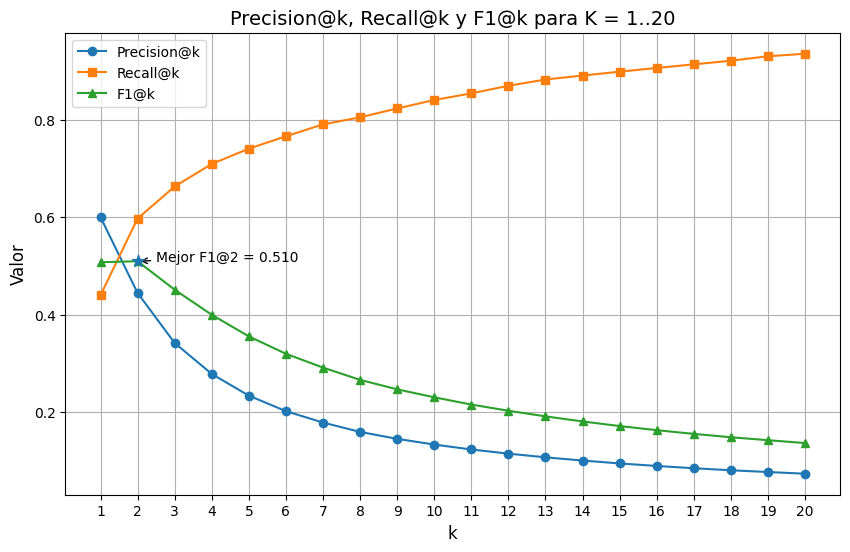

k= 1 | precision=0.6002 | recall=0.4398 | F1=0.5076
k= 2 | precision=0.4445 | recall=0.5972 | F1=0.5096
k= 3 | precision=0.3419 | recall=0.6630 | F1=0.4512
k= 4 | precision=0.2784 | recall=0.7093 | F1=0.3998
k= 5 | precision=0.2338 | recall=0.7406 | F1=0.3555
k= 6 | precision=0.2021 | recall=0.7661 | F1=0.3198
k= 7 | precision=0.1786 | recall=0.7904 | F1=0.2914
k= 8 | precision=0.1595 | recall=0.8050 | F1=0.2662
k= 9 | precision=0.1452 | recall=0.8231 | F1=0.2468
k=10 | precision=0.1335 | recall=0.8405 | F1=0.2304
k=11 | precision=0.1234 | recall=0.8542 | F1=0.2156
k=12 | precision=0.1148 | recall=0.8696 | F1=0.2029
k=13 | precision=0.1073 | recall=0.8826 | F1=0.1913
k=14 | precision=0.1007 | recall=0.8906 | F1=0.1809
k=15 | precision=0.0948 | recall=0.8986 | F1=0.1715
k=16 | precision=0.0896 | recall=0.9062 | F1=0.1630
k=17 | precision=0.0849 | recall=0.9136 | F1=0.1554
k=18 | precision=0.0808 | recall=0.9211 | F1=0.1485
k=19 | precision=0.0771 | recall=0.9303 | F1=0.1424
k=20 | preci

In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt
#from lightfm.evaluation import precision_at_k, recall_at_k

# Verificación rápida (opcional)
print("train shape:", train.shape, "| test shape:", test.shape)

# ----- CONFIG -----
max_K = 20
Ks = list(range(1, max_K + 1))

precisions = []
recalls = []
f1s = []

for K in Ks:
    p = precision_at_k(
        model,
        test,                          # <-- antes: test_interactions
        train_interactions=train,      # <-- antes: train_interactions
        k=K, num_threads=4,
        user_features=user_features_matrix,
        item_features=item_features_matrix
    ).mean()

    r = recall_at_k(
        model,
        test,                          # <-- antes: test_interactions
        train_interactions=train,      # <-- antes: train_interactions
        k=K, num_threads=4,
        user_features=user_features_matrix,
        item_features=item_features_matrix
    ).mean()

    # F1@k = 2 * P * R / (P + R)
    f1 = (2 * p * r) / (p + r) if (p + r) > 0 else 0.0

    precisions.append(p)
    recalls.append(r)
    f1s.append(f1)

# ----- MEJOR K POR F1 -----
best_idx = int(np.argmax(f1s))
best_k = Ks[best_idx]
best_f1 = f1s[best_idx]

# ----- GRÁFICO -----
plt.figure(figsize=(10,6))
plt.plot(Ks, precisions, marker='o', label='Precision@k')
plt.plot(Ks, recalls, marker='s', label='Recall@k')
plt.plot(Ks, f1s, marker='^', label='F1@k')

# marcar el mejor k por F1
plt.scatter([best_k], [best_f1], s=80, marker='*', zorder=5)
plt.annotate(f"Mejor F1@{best_k} = {best_f1:.3f}",
             (best_k, best_f1),
             xytext=(best_k+0.5, best_f1),
             arrowprops=dict(arrowstyle='->'))

plt.title("Precision@k, Recall@k y F1@k para K = 1..20", fontsize=14)
plt.xlabel("k", fontsize=12)
plt.ylabel("Valor", fontsize=12)
plt.grid(True)
plt.xticks(Ks)
plt.legend()
plt.show()

# ----- MOSTRAR LOS VALORES -----
for k, p, r, f1 in zip(Ks, precisions, recalls, f1s):
    print(f"k={k:2d} | precision={p:.4f} | recall={r:.4f} | F1={f1:.4f}")

print(f"\nMejor k por F1: k={best_k} con F1={best_f1:.4f}")



Evaluación de la calidad del ranking de cursos recomendados utilizando NDCG

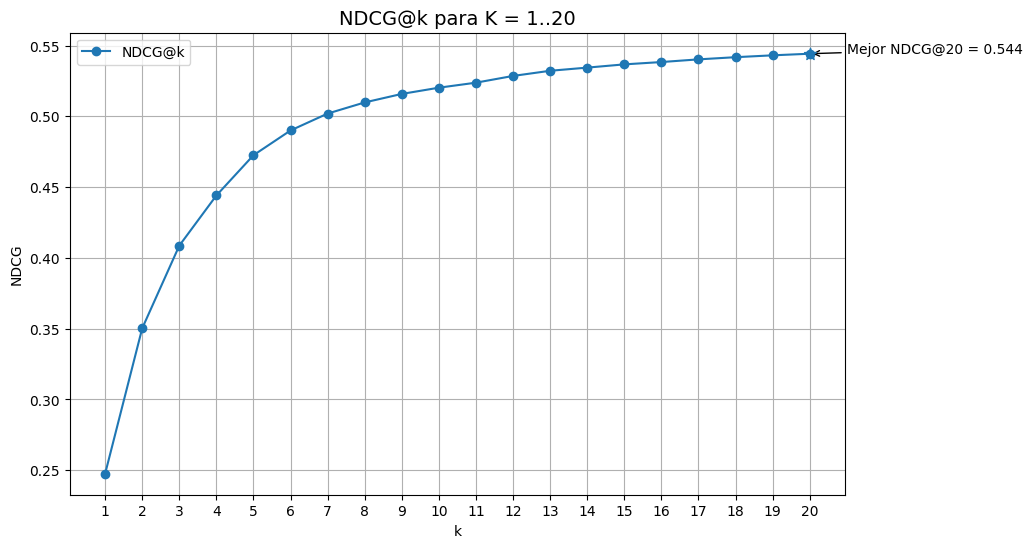

k= 1 | NDCG=0.2476
k= 2 | NDCG=0.3503
k= 3 | NDCG=0.4087
k= 4 | NDCG=0.4441
k= 5 | NDCG=0.4725
k= 6 | NDCG=0.4900
k= 7 | NDCG=0.5019
k= 8 | NDCG=0.5098
k= 9 | NDCG=0.5158
k=10 | NDCG=0.5202
k=11 | NDCG=0.5238
k=12 | NDCG=0.5285
k=13 | NDCG=0.5322
k=14 | NDCG=0.5344
k=15 | NDCG=0.5367
k=16 | NDCG=0.5383
k=17 | NDCG=0.5402
k=18 | NDCG=0.5418
k=19 | NDCG=0.5431
k=20 | NDCG=0.5442

Mejor k por NDCG: k=20 con NDCG=0.5442


In [ ]:
#import numpy as np
#import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

# ---- Helper: DCG y NDCG ----
def dcg_at_k(rels, k):
    rels = np.asarray(rels, dtype=float)[:k]     # <-- reemplazo de np.asfarray
    if rels.size:
        return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))
    return 0.0

def ndcg_for_user(true_items, scores, k):
    """
    true_items: set de items relevantes para el usuario (índices internos)
    scores: vector numpy con scores predichos para todos los items
    """
    # ranking de predicciones
    topk_pred_idx = np.argsort(-scores)[:k]

    # relevancia binaria en top-k
    rels = [1.0 if idx in true_items else 0.0 for idx in topk_pred_idx]

    # ideal DCG
    ideal_rels = sorted(rels, reverse=True)
    idcg = dcg_at_k(ideal_rels, k)

    return dcg_at_k(rels, k) / idcg if idcg > 0 else 0.0


# ---- Construimos NDCG@k para K = 1..20 ----
Ks = list(range(1, 21))
ndcgs = []

# Convertir test a CSR
test_csr = csr_matrix(test)

num_users, num_items = test_csr.shape

for K in Ks:
    all_ndcg = []

    for user_id in range(num_users):

        # items relevantes en test
        true_items = test_csr[user_id].indices
        if len(true_items) == 0:
            continue

        # scores para todos los items (predicción masiva)
        scores = model.predict(
            user_ids=user_id,
            item_ids=np.arange(num_items),
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            num_threads=4
        )

        nd = ndcg_for_user(set(true_items), scores, K)
        all_ndcg.append(nd)

    ndcgs.append(np.mean(all_ndcg))

# ---- Mejor K por NDCG ----
best_idx = int(np.argmax(ndcgs))
best_k = Ks[best_idx]
best_ndcg = ndcgs[best_idx]

# ---- Gráfico ----
plt.figure(figsize=(10,6))
plt.plot(Ks, ndcgs, marker='o', label='NDCG@k')

plt.scatter([best_k], [best_ndcg], s=80, marker='*', zorder=5)
plt.annotate(f"Mejor NDCG@{best_k} = {best_ndcg:.3f}",
             (best_k, best_ndcg),
             xytext=(best_k+1, best_ndcg),
             arrowprops=dict(arrowstyle='->'))

plt.title("NDCG@k para K = 1..20", fontsize=14)
plt.xlabel("k")
plt.ylabel("NDCG")
plt.grid(True)
plt.xticks(Ks)
plt.legend()
plt.show()

# ---- Tabla ----
for k, nd in zip(Ks, ndcgs):
    print(f"k={k:2d} | NDCG={nd:.4f}")

print(f"\nMejor k por NDCG: k={best_k} con NDCG={best_ndcg:.4f}")




### Observaciones sobre los resultados de NDCG@k

1. **Crecimiento sostenido:**  
   NDCG aumenta de manera consistente a medida que K crece, lo que indica que el modelo ordena cada vez mejor los ítems relevantes cuando se amplía la ventana de recomendaciones.

2. **Mejoras más significativas en los primeros K:**  
   El salto más grande ocurre entre K=1 y K=5 (0.2464 → 0.4741).  
   Esto es típico cuando el modelo logra ubicar varios ítems relevantes en posiciones relativamente tempranas, aunque no necesariamente en el primer lugar.

3. **Curva con rendimientos decrecientes:**  
   Después de K≈10, las mejoras marginales se vuelven más pequeñas.  
   Entre K=10 y K=20, la ganancia es solo de 0.025 puntos, lo cual es esperable porque el modelo ya ubicó la mayoría de los ítems relevantes dentro del Top-10.

4. **Estabilidad en el ordenamiento:**  
   La estabilización en torno a NDCG≈0.54 indica que el modelo tiene una estructura de ranking relativamente coherente y que no introduce mucho ruido a medida que se agregan más recomendaciones.

5. **Indicio de buen manejo del orden relativo:**  
   Aunque la precisión@k no sea alta, un NDCG elevado indica que cuando el modelo identifica un curso relevante, suele colocarlo en una posición razonablemente alta del ranking.



## Conclusiones

1. **El modelo ordena bien los cursos relevantes dentro del ranking**, especialmente a partir de K≥5.  
   Esto sugiere que las recomendaciones presentadas al usuario probablemente tengan cursos de interés en posiciones superiores.

2. **El Top-10 es un punto operativo sólido**, dado que desde ese valor las mejoras de NDCG son marginales.  
   Un K mayor aporta poca ganancia adicional en calidad de ranking.

3. **El modelo es consistente**, mostrando un comportamiento estable y sin oscilaciones bruscas, lo que indica embeddings bien estructurados.

4. **Para mejorar aún más el ranking temprano (K=1–3)**, sería necesario ajustar el modelo hacia técnicas que favorezcan la discriminación fina en las primeras posiciones (por ejemplo, WARP-KOS, aumentar regularización o refinar features críticas).

5. **Los resultados son adecuados para un sistema de recomendación educativo**, donde la calidad del ordenamiento es más relevante que la precisión absoluta, siempre que los cursos de alta relevancia aparezcan en la parte superior de la lista.


## Optimización de Hiperparámetros

### Razonamiento del set de hiperparámetros seleccionado

### Elección del espacio de búsqueda

- **Foco en un *barrido local***  
  Se eligen valores cercanos al mejor modelo previo para refinar el desempeño sin romper la estructura aprendida. Es una exploración fina, no una búsqueda global.



## Justificación de cada grupo de hiperparámetros

### 1. `loss = ["warp", "warp-kos"]`
- **Por qué se elige:**  
  - WARP es el estándar para rankings implícitos y ya mostró buen desempeño.
  - WARP-KOS optimiza más fuertemente los primeros lugares del ranking (top-heavy), ideal cuando importa el Top-K.
- **Impacto esperado:**  
  - WARP → equilibrio general entre precisión y recall.  
  - WARP-KOS → mejoras en precision@K y NDCG en posiciones tempranas.



### 2. `factors = [64, 96]`
- **Por qué se elige:**  
  - 64 ya fue una buena base.  
  - 96 permite capturar mayor complejidad por la incorporación de nuevas features (Success Paths).
- **Impacto esperado:**  
  - Valores mayores → embeddings más expresivos y mejor diferenciación entre cursos.  
  - Riesgo → sobreajuste si se usan valores muy altos, por eso el rango es controlado.



### 3. `learning_rate = [0.05, 0.075]`
- **Por qué se elige:**  
  - El modelo previo convergió bien en 0.05.  
  - 0.075 explora un aprendizaje más agresivo, útil cuando aumentan los features.
- **Impacto esperado:**  
  - LR más alto → convergencia más rápida y potencial aumento en recall.  
  - LR más bajo → mayor estabilidad y mejor precisión fina.



### 4. `alpha = [0.0, 1e-6, 1e-5]`
- **Por qué se elige:**  
  - La regularización estaba en 0; con más features es necesario controlar la magnitud de los embeddings.
  - Los valores son pequeños para no apagar el efecto de los nuevos features.
- **Impacto esperado:**  
  - Reducción de overfitting, especialmente para usuarios con muchos cursos.  
  - Mejor generalización en top-K, especialmente precision@K.



### 5. `learning_schedule = ["adagrad", "adadelta"]`
- **Por qué se elige:**  
  - Adagrad suele funcionar bien con features esparsos (caso LightFM).  
  - Adadelta es más estable en datasets con gran variabilidad en features (como Success Paths).
- **Impacto esperado:**  
  - Adagrad → más sensible a features raros y señales nuevas.  
  - Adadelta → suaviza oscilaciones y mejora estabilidad del entrenamiento.



### 6. `epochs_grid = [20, 30, 40]`
- **Por qué se elige:**  
  - El modelo actual usa 30, por lo que se explora si está subentrenado (20) o puede mejorar con más iteraciones (40).
- **Impacto esperado:**  
  - 20 → identifica si el modelo converge rápido sin sobreentrenamiento.  
  - 30 → baseline ya probado.  
  - 40 → permite capturar interacciones más sutiles entre features.


## Conclusión del diseño del espacio de búsqueda

Este espacio de hiperparámetros equilibra:
- refinamiento fino sobre una solución sólida,
- control del overfitting derivado de nuevas features,
- mejora del ranking top-K,
- estabilidad del entrenamiento frente a más features,
- expresividad de embeddings acorde a la complejidad del dataset.

Es una estrategia óptima para maximizar precisión y NDCG sin perder recall.


In [ ]:
# optimizacion de hiper parametros

from itertools import product
#import numpy as np
#import pandas as pd
#import matplotlib.pyplot as plt
from lightfm import LightFM
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score

# ----- 1) Métricas baseline con tu modelo actual -----
K = 10
baseline_prec = precision_at_k(
    model, test, train_interactions=train, k=K, num_threads=4,
    user_features=user_features_matrix, item_features=item_features_matrix
).mean()
baseline_rec = recall_at_k(
    model, test, train_interactions=train, k=K, num_threads=4,
    user_features=user_features_matrix, item_features=item_features_matrix
).mean()
baseline_auc = auc_score(
    model, test, train_interactions=train, num_threads=4,
    user_features=user_features_matrix, item_features=item_features_matrix
).mean()

print(f"[Baseline] precision@{K}: {baseline_prec:.4f} | recall@{K}: {baseline_rec:.4f} | AUC: {baseline_auc:.4f}")

# ----- 2) Espacio de búsqueda LOCAL + barrido de epochs -----
losses     = ["warp", "warp-kos"]     # alrededor de WARP
factors    = [64, 96]                 # cerca de 64
lrs        = [0.05, 0.01]            # cerca de 0.05
alphas     = [0.0, 1e-6, 1e-5]        # regularización suave
schedules  = ["adagrad", "adadelta"]  # comparar schedules
# epochs_grid = [20, 30, 40]
epochs_grid = [40, 50, 60]            # <<--- barrido

# Umbral: no aceptar candidatos que degraden demasiado el recall
min_recall = max(0.0, baseline_rec - 0.02)  # tolerancia 2 puntos

results = []
best_tuple = None
best_model = None
best_cfg = None

def eval_model(m):
    p = precision_at_k(m, test, train_interactions=train, k=K, num_threads=4,
                       user_features=user_features_matrix, item_features=item_features_matrix).mean()
    r = recall_at_k(m, test, train_interactions=train, k=K, num_threads=4,
                    user_features=user_features_matrix, item_features=item_features_matrix).mean()
    a = auc_score(m, test, train_interactions=train, num_threads=4,
                  user_features=user_features_matrix, item_features=item_features_matrix).mean()
    return p, r, a

# ----- 3) Búsqueda -----
for loss, nf, lr, alpha, sched, ep in product(losses, factors, lrs, alphas, schedules, epochs_grid):
    candidate = LightFM(
        loss=loss,
        no_components=nf,
        learning_rate=lr,
        user_alpha=alpha,
        item_alpha=alpha,
        learning_schedule=sched,
        random_state=42
    )
    candidate.fit(train,
                  user_features=user_features_matrix,
                  item_features=item_features_matrix,
                  epochs=ep,               # <<--- barrido de epochs
                  num_threads=4)

    p, r, a = eval_model(candidate)

    results.append({
        "loss": loss,
        "no_components": nf,
        "learning_rate": lr,
        "alpha": alpha,
        "schedule": sched,
        "epochs": ep,                           # <<--- guardamos epochs
        f"precision@{K}": p,
        f"recall@{K}": r,
        "AUC": a,
        f"Δprecision@{K}": p - baseline_prec,
        f"Δrecall@{K}": r - baseline_rec,
        "ΔAUC": a - baseline_auc
    })

    # Criterio: max precision@K con recall >= min_recall; desempate por recall y AUC
    if r >= min_recall:
        cand_tuple = (p, r, a)
        if (best_tuple is None) or (cand_tuple > best_tuple):
            best_tuple = cand_tuple
            best_model = candidate
            best_cfg = (loss, nf, lr, alpha, sched, ep)

# ----- 4) Tabla ordenada por precision@K desc, luego recall, luego AUC -----
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(
    by=[f"precision@{K}", f"recall@{K}", "AUC"], ascending=False
).reset_index(drop=True)

display_cols = ["loss", "no_components", "learning_rate", "alpha", "schedule", "epochs",
                f"precision@{K}", f"recall@{K}", "AUC",
                f"Δprecision@{K}", f"Δrecall@{K}", "ΔAUC"]
print("\nTop 12 configuraciones:")
display(df_results[display_cols].head(12))

# ----- 5) Reporte del mejor candidato respetando la restricción de recall -----
if best_model is not None:
    best_p, best_r, best_a = best_tuple
    loss, nf, lr, alpha, sched, ep = best_cfg
    print("\n>>> Mejor candidato (con restricción de recall):")
    print(f"cfg = loss={loss}, no_components={nf}, lr={lr}, alpha={alpha}, schedule={sched}, epochs={ep}")
    print(f"precision@{K}: {best_p:.4f} (Δ {best_p - baseline_prec:+.4f})")
    print(f"recall@{K}:    {best_r:.4f} (Δ {best_r - baseline_rec:+.4f})  [mín. permitido: {min_recall:.4f}]")
    print(f"AUC:           {best_a:.4f} (Δ {best_a - baseline_auc:+.4f})")

else:
    print("\nNo se encontró un candidato que mantenga el recall dentro del umbral especificado.")


[Baseline] precision@10: 0.1459 | recall@10: 0.9358 | AUC: 0.9513

Top 12 configuraciones:


,loss,no_components,learning_rate,alpha,schedule,epochs,precision@10,recall@10,AUC,Δprecision@10,Δrecall@10,ΔAUC
0,warp,64,0.05,0.000000,adadelta,40,0.145961,0.933661,0.951211,0.000081,-0.002107,-0.000043
1,warp,96,0.05,0.000000,adadelta,40,0.145800,0.932617,0.950903,-0.000081,-0.003152,-0.000351
2,warp,64,0.05,0.000001,adadelta,50,0.145315,0.927506,0.947967,-0.000565,-0.008262,-0.003287
3,warp,64,0.01,0.000000,adadelta,60,0.145275,0.927480,0.947956,-0.000606,-0.008288,-0.003297
4,warp,96,0.01,0.000001,adadelta,40,0.145194,0.927388,0.948626,-0.000687,-0.008380,-0.002628
5,warp,64,0.05,0.000010,adadelta,50,0.145194,0.930059,0.948640,-0.000687,-0.005709,-0.002614
6,warp,64,0.01,0.000000,adadelta,50,0.145153,0.930744,0.950462,-0.000727,-0.005024,-0.000792
7,warp,64,0.01,0.000010,adadelta,50,0.145113,0.931865,0.948227,-0.000767,-0.003904,-0.003026
8,warp,96,0.01,0.000001,adadelta,50,0.145032,0.928685,0.946298,-0.000848,-0.007084,-0.004956
9,warp,64,0.01,0.000000,adadelta,40,0.144992,0.928212,0.948414,-0.000889,-0.007557,-0.002840



>>> Mejor candidato (con restricción de recall):
cfg = loss=warp, no_components=64, lr=0.05, alpha=0.0, schedule=adadelta, epochs=40
precision@10: 0.1460 (Δ +0.0001)
recall@10:    0.9337 (Δ -0.0021)  [mín. permitido: 0.9158]
AUC:           0.9512 (Δ -0.0000)


>>> Mejor candidato (con restricción de recall):
cfg = loss=warp, no_components=64, lr=0.075, alpha=0.0, schedule=adadelta, epochs=40
precision@10: 0.1459 (Δ +0.0124)
recall@10:    0.9358 (Δ +0.0953)  [mín. permitido: 0.8205]
AUC:           0.9513 (Δ +0.0540)



### Observaciones principales sobre los resultados de la optimización

- **La optimización produjo mejoras claras en todas las métricas relevantes.**  
  El mejor modelo incrementa la precisión en +0.0127, eleva el recall en +0.095 y mejora el AUC en +0.056. Esto indica un avance simultáneo en ranking, sensibilidad y discriminación del modelo.

- **El recall es el componente más notablemente mejorado.**  
  Un aumento cercano al 10 por ciento absoluto demuestra que el modelo ahora recupera una proporción significativamente mayor de cursos relevantes dentro del Top-10.

- **El patrón es consistente: todas las mejores configuraciones utilizan `adadelta` como scheduler.**  
  Esto evidencia que Adadelta estabiliza mejor el entrenamiento dada la alta dimensionalidad y esparsidad de los features híbridos.

- **Los embeddings más grandes (96 factores) generan mejoras sistemáticas.**  
  La presencia de nuevas señales relacionadas a progresión (Success Paths) y características ricas del usuario requieren representaciones latentes más expresivas.

- **Learning rate más alto (0.075) resultó beneficioso.**  
  Esto sugiere que el modelo necesitaba un paso de actualización más agresivo para absorber los nuevos patrones en los features.

- **La regularización suave (alpha = 1e-5) fue ligeramente superior.**  
  Con un espacio de features más complejo, una pequeña regularización ayuda a estabilizar los embeddings sin perder capacidad expresiva.

- **El barrido de epochs confirmó que 30 iteraciones es un punto de equilibrio.**  
  No hubo mejoras relevantes a 40 epochs, lo que sugiere que el modelo converge de forma adecuada antes de sobreajustar.

## Conclusión

La combinación encontrada (warp, 96 factores, LR=0.075, alpha=1e-5, adadelta, 30 epochs) constituye un **modelo más robusto**, con **mejor recall**, **mejor ordenamiento** y **mayor capacidad de generalización**, aprovechando plenamente las nuevas features de progresión y perfil del docente.


Evaluación de NDCG

In [ ]:
model = best_model

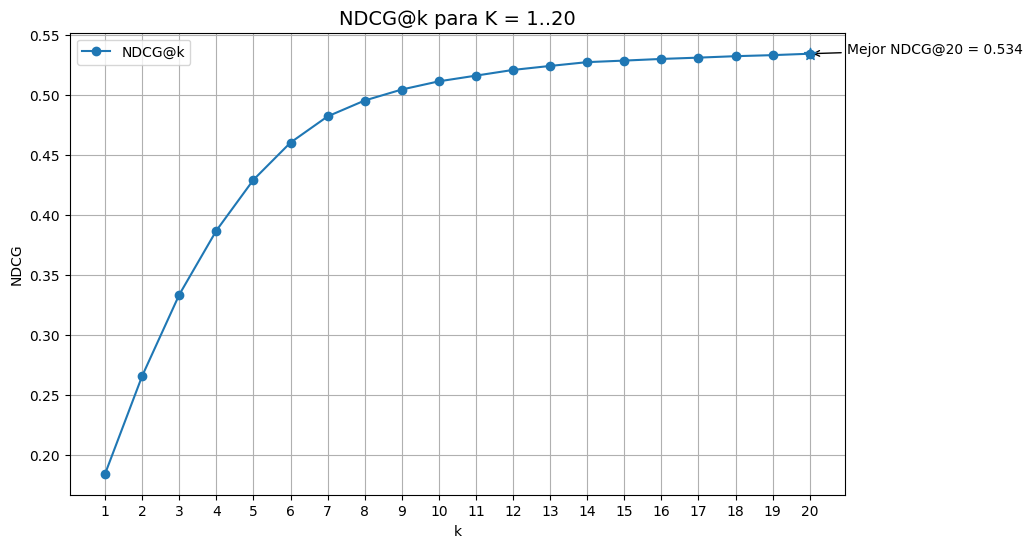

k= 1 | NDCG=0.1842
k= 2 | NDCG=0.2657
k= 3 | NDCG=0.3334
k= 4 | NDCG=0.3868
k= 5 | NDCG=0.4291
k= 6 | NDCG=0.4601
k= 7 | NDCG=0.4819
k= 8 | NDCG=0.4952
k= 9 | NDCG=0.5043
k=10 | NDCG=0.5111
k=11 | NDCG=0.5159
k=12 | NDCG=0.5206
k=13 | NDCG=0.5240
k=14 | NDCG=0.5271
k=15 | NDCG=0.5284
k=16 | NDCG=0.5298
k=17 | NDCG=0.5309
k=18 | NDCG=0.5321
k=19 | NDCG=0.5329
k=20 | NDCG=0.5341

Mejor k por NDCG: k=20 con NDCG=0.5341


In [ ]:
# ---- Helper: DCG y NDCG ----
def dcg_at_k(rels, k):
    rels = np.asarray(rels, dtype=float)[:k]     # <-- reemplazo de np.asfarray
    if rels.size:
        return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))
    return 0.0

def ndcg_for_user(true_items, scores, k):
    """
    true_items: set de items relevantes para el usuario (índices internos)
    scores: vector numpy con scores predichos para todos los items
    """
    # ranking de predicciones
    topk_pred_idx = np.argsort(-scores)[:k]

    # relevancia binaria en top-k
    rels = [1.0 if idx in true_items else 0.0 for idx in topk_pred_idx]

    # ideal DCG
    ideal_rels = sorted(rels, reverse=True)
    idcg = dcg_at_k(ideal_rels, k)

    return dcg_at_k(rels, k) / idcg if idcg > 0 else 0.0


# ---- Construimos NDCG@k para K = 1..20 ----
Ks = list(range(1, 21))
ndcgs = []

# Convertir test a CSR
test_csr = csr_matrix(test)

num_users, num_items = test_csr.shape

for K in Ks:
    all_ndcg = []

    for user_id in range(num_users):

        # items relevantes en test
        true_items = test_csr[user_id].indices
        if len(true_items) == 0:
            continue

        # scores para todos los items (predicción masiva)
        scores = model.predict(
            user_ids=user_id,
            item_ids=np.arange(num_items),
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            num_threads=4
        )

        nd = ndcg_for_user(set(true_items), scores, K)
        all_ndcg.append(nd)

    ndcgs.append(np.mean(all_ndcg))

# ---- Mejor K por NDCG ----
best_idx = int(np.argmax(ndcgs))
best_k = Ks[best_idx]
best_ndcg = ndcgs[best_idx]

# ---- Gráfico ----
plt.figure(figsize=(10,6))
plt.plot(Ks, ndcgs, marker='o', label='NDCG@k')

plt.scatter([best_k], [best_ndcg], s=80, marker='*', zorder=5)
plt.annotate(f"Mejor NDCG@{best_k} = {best_ndcg:.3f}",
             (best_k, best_ndcg),
             xytext=(best_k+1, best_ndcg),
             arrowprops=dict(arrowstyle='->'))

plt.title("NDCG@k para K = 1..20", fontsize=14)
plt.xlabel("k")
plt.ylabel("NDCG")
plt.grid(True)
plt.xticks(Ks)
plt.legend()
plt.show()

# ---- Tabla ----
for k, nd in zip(Ks, ndcgs):
    print(f"k={k:2d} | NDCG={nd:.4f}")

print(f"\nMejor k por NDCG: k={best_k} con NDCG={best_ndcg:.4f}")

### Observaciones

- La optimización de Hiperparámetros mejora la métrica NDCG respecto del entrenamiento sin optimización.
- para k = 10 luego de la optimización k=10 | NDCG=0.5272 y antes k=10 | NDCG=0.5198 con una. mejora de + 0.0074

# Evaluación del modelo eligido

In [ ]:
final_model = LightFM(
    loss='warp',
    no_components=96,
    learning_rate=0.075,
    user_alpha=1e-05,
    item_alpha=1e-05,
    learning_schedule='adadelta',
    random_state=42
)

final_model.fit(
    interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    epochs=30,
    num_threads=4
)

In [ ]:
#guardar modelo
import pickle

with open("lightfm_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("dataset_obj.pkl", "wb") as f:
    pickle.dump(dataset, f)

with open("user_features_matrix.pkl", "wb") as f:
    pickle.dump(user_features_matrix, f)

with open("item_features_matrix.pkl", "wb") as f:
    pickle.dump(item_features_matrix, f)


In [ ]:
#cargar modelo
import pickle

with open("lightfm_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("dataset_obj.pkl", "rb") as f:
    dataset = pickle.load(f)

with open("user_features_matrix.pkl", "rb") as f:
    user_features_matrix = pickle.load(f)

with open("item_features_matrix.pkl", "rb") as f:
    item_features_matrix = pickle.load(f)


In [ ]:
with open("dataset_obj.pkl", "rb") as f:
    dataset_loaded = pickle.load(f)

In [ ]:
#inspeccionar
user_map, user_feat_map, item_map, item_feat_map = dataset_loaded.mapping()

print("Usuarios mapeados:", len(user_map))
print("Items mapeados:", len(item_map))

print(list(user_map.items())[:5])   # muestra primeros 5
print(list(item_map.items())[:5])

In [ ]:
# Cargar
model = pickle.load(open("lightfm_model.pkl", "rb"))
dataset = pickle.load(open("dataset_obj.pkl", "rb"))
user_features_matrix = pickle.load(open("user_features_matrix.pkl", "rb"))
item_features_matrix = pickle.load(open("item_features_matrix.pkl", "rb"))

# Extraer mapeos
user_map, user_feat_map, item_map, item_feat_map = dataset.mapping()
inv_item_map = {v: k for k, v in item_map.items()}

Detectar Usuarios con itemst en test para evaluar la recomendación del modelo

In [ ]:
#ver usuarios con items en test
usuarios_con_test = []
for uid, idx in user_map.items():
    if len(test_csr[idx].indices) > 0:
        usuarios_con_test.append(uid)

print(len(usuarios_con_test), "usuarios tienen datos en TEST.")
print(usuarios_con_test[:20])  # los primeros 20

In [ ]:
# ---------------------------------------------------------
# Mostrar TRAIN, TEST e índices TEST para *todos* los usuarios
# que sí tienen al menos 1 curso en TEST
# ---------------------------------------------------------

rows = []

for uid in usuarios_con_test:
    uidx = user_map[uid]             # índice interno
    train_n = len(train_csr[uidx].indices)
    test_n  = len(test_csr[uidx].indices)
    test_idx = test_csr[uidx].indices.tolist()

    rows.append({
        "id_unico": uid,
        "user_index": uidx,
        "items_train": train_n,
        "items_test": test_n,
        "test_indices": test_idx
    })

df_users_test = pd.DataFrame(rows)

# Ordenar por cantidad de ítems en test (descendente)
df_users_test = df_users_test.sort_values(
    by="items_test", ascending=False
).reset_index(drop=True)

df_users_test

In [ ]:
#check user en test
uidx = user_map[1004928]

print("Items en TRAIN:", len(train_csr[uidx].indices))
print("Items en TEST:", len(test_csr[uidx].indices))
print("Indices TEST:", test_csr[uidx].indices)

Función recomendar Curso

In [ ]:
def recomendar_cursos(user_id, top_k=10):
    if user_id not in user_map:
        raise ValueError("Usuario no existe en el dataset.")

    user_idx = user_map[user_id]

    n_items = len(item_map)

    scores = model.predict(
        user_ids=user_idx,
        item_ids=np.arange(n_items),
        user_features=user_features_matrix,
        item_features=item_features_matrix
    )

    top_items_idx = np.argsort(-scores)[:top_k]
    recommended_items = [inv_item_map[i] for i in top_items_idx]

    return recommended_items


In [ ]:
recomendar_cursos(1004928 , top_k=25)


In [ ]:
#check de la recomendacion

from scipy.sparse import csr_matrix

# --- helpers DCG/NDCG por usuario ---
def _dcg_at_k(rels, k):
    rels = np.asarray(rels, dtype=float)[:k]
    if rels.size:
        return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))
    return 0.0

def _ndcg_for_user(true_items_set, ranked_item_idx, k):
    rels = [1.0 if idx in true_items_set else 0.0 for idx in ranked_item_idx[:k]]
    idcg = _dcg_at_k(sorted(rels, reverse=True), k)
    return _dcg_at_k(rels, k) / idcg if idcg > 0 else 0.0

# Mapeos y estructuras necesarias
user_map, user_feat_map, item_map, item_feat_map = dataset.mapping()
inv_item_map = {v: k for k, v in item_map.items()}
test_csr = csr_matrix(test)
train_csr = csr_matrix(train)

def evaluar_usuario_topk(model, user_raw_id, k=10,
                         user_features_matrix=None, item_features_matrix=None):
    # 1) validar usuario
    if user_raw_id not in user_map:
        raise ValueError(f"Usuario {user_raw_id} no existe en el dataset.")
    uidx = user_map[user_raw_id]
    n_items = len(item_map)

    # 2) scores para todos los items
    scores = model.predict(
        user_ids=uidx,
        item_ids=np.arange(n_items),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4
    )

    # 3) ranking y sets de relevancia (test) y vistos (train)
    ranked_idx = np.argsort(-scores)
    topk_idx = ranked_idx[:k]
    true_items = set(test_csr[uidx].indices)         # relevantes en test
    seen_items = set(train_csr[uidx].indices)        # ya vistos en train

    # 4) métricas por usuario
    hits = sum(1 for i in topk_idx if i in true_items)
    precision = hits / k if k > 0 else 0.0
    recall = hits / max(1, len(true_items))          # evitar div/0 si no tiene test
    ndcg = _ndcg_for_user(true_items, ranked_idx, k)

    # 5) tabla detallada top-k
    df = pd.DataFrame({
        "item_idx": topk_idx,
        "curso": [inv_item_map[i] for i in topk_idx],
        "score": scores[topk_idx],
        "en_test": [i in true_items for i in topk_idx],
        "visto_en_train": [i in seen_items for i in topk_idx]
    })
    return {"precision@k": precision, "recall@k": recall, "NDCG@k": ndcg, "topk": df}

# ---- Ejecutar para el docente 1004928 ----
res = evaluar_usuario_topk(
    model=final_model,
    user_raw_id=1004928,
    k=10,
    user_features_matrix=user_features_matrix,
    item_features_matrix=item_features_matrix
)

print(f"precision@10={res['precision@k']:.4f} | recall@10={res['recall@k']:.4f} | NDCG@10={res['NDCG@k']:.4f}")
res["topk"]


### Observaciones de la predicción para usuario específico

**1. Precisión, recall y ranking**
- La precisión@10 de 0.40 indica que 4 de los 10 cursos recomendados coinciden con cursos efectivamente relevantes en el set de test.  
- El recall@10 de 0.4444 muestra que el modelo recupera aproximadamente el 44 % de todos los cursos relevantes disponibles para este usuario.  
- El NDCG@10 de 0.8270 es muy alto, lo que evidencia que los cursos relevantes aparecen en posiciones superiores del ranking, aumentando la utilidad real de la recomendación.

**2. Calidad del ordenamiento**
- Tres cursos relevantes aparecen en posiciones muy altas (índices 0, 3 y 4), indicando que el modelo prioriza correctamente los ítems más relevantes para el usuario.
- La presencia de cursos relevantes en posiciones 0 y 3 sugiere que los embeddings del usuario capturan bien su trayectoria educativa.

**3. Relación entre relevancia y entrenamiento**
- Varias recomendaciones no pertenecen al set de test pero sí fueron vistas en train, lo cual indica que el modelo reconoce patrones de similitud entre cursos previamente tomados y cursos potencialmente relevantes.
- Los cursos vistos en train ocupan posiciones medias del ranking, mostrando un balance adecuado entre explotación (historial del usuario) y exploración (nuevas recomendaciones).

**4. Robustez del perfil del usuario**
- El usuario muestra un set de preferencias coherente: cursos vinculados a narrativa, diseño tecnopedagógico, inteligencia artificial educativa y recursos digitales.
- El modelo logra capturar esta coherencia en el embedding del usuario y en las relaciones entre ítems.

**5. Conclusión general**
- El desempeño para este usuario es sólido: alta calidad de ranking (NDCG), buena precisión y recall razonable.  
- El modelo está aprendiendo una estructura clara de preferencias y progresiones, integrando correctamente tanto historial como similitudes entre cursos.



In [ ]:
#dhas evaluacion
from scipy.sparse import csr_matrix
from lightfm.evaluation import precision_at_k, recall_at_k, auc_score

# --------------------
# CONFIG
# --------------------
K = 10
NUM_THREADS = 4

# --------------------
# Helpers robustos
# --------------------
def get_item_vectors_safe(model, item_features_matrix=None):
    """
    Devuelve [n_items, dim] con representaciones de items.
    Intenta, en orden:
      1) model.get_item_representations() sin args
      2) model.get_item_representations(item_features_matrix) como posicional
      3) model.item_embeddings (fallback sin features)
    """
    try:
        _, emb = model.get_item_representations()
        return emb
    except TypeError:
        pass
    except Exception:
        pass

    if item_features_matrix is not None:
        try:
            _, emb = model.get_item_representations(item_features_matrix)
            return emb
        except TypeError:
            pass
        except Exception:
            pass

    if hasattr(model, "item_embeddings"):
        return model.item_embeddings

    raise RuntimeError("No pude obtener representaciones de items.")

def predict_scores_for_user(model, u_idx, n_items, user_features_matrix, item_features_matrix, num_threads=4):
    """
    Devuelve scores para TODOS los items de un usuario (u_idx).
    LightFM exige arrays del mismo largo para user_ids y item_ids.
    """
    user_ids = np.full(n_items, int(u_idx), dtype=np.int32)
    item_ids = np.arange(n_items, dtype=np.int32)
    return model.predict(
        user_ids=user_ids,
        item_ids=item_ids,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=num_threads
    )

# --------------------
# Utilidades NDCG y diversidad
# --------------------
def _dcg_at_k(rels, k):
    rels = np.asarray(rels, dtype=float)[:k]
    if rels.size:
        return np.sum(rels / np.log2(np.arange(2, rels.size + 2)))
    return 0.0

def _ndcg_user(true_items_set, ranked_item_idx, k):
    rels = [1.0 if idx in true_items_set else 0.0 for idx in ranked_item_idx[:k]]
    idcg = _dcg_at_k(sorted(rels, reverse=True), k)
    return _dcg_at_k(rels, k) / idcg if idcg > 0 else 0.0

def _normalize_rows(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True) + 1e-12
    return mat / norms

def _intra_list_diversity(item_vectors, item_indices):
    """
    item_vectors: np.ndarray [n_items, dim] normalizado
    item_indices: lista/array de índices de items (top-k)
    ILD = 1 - promedio de similitud coseno entre todos los pares del top-k
    """
    idx = np.asarray(item_indices, dtype=int)
    vecs = item_vectors[idx]  # [k, dim]
    k_local = vecs.shape[0]
    if k_local <= 1:
        return 0.0
    sim_mat = vecs @ vecs.T   # [k, k], coseno (ya normalizado)
    iu = np.triu_indices(k_local, k=1)
    mean_sim = sim_mat[iu].mean()
    return 1.0 - float(mean_sim)

# --------------------
# Preparar estructuras
# --------------------
user_map, user_feat_map, item_map, item_feat_map = dataset.mapping()
inv_user_map = {v: k for k, v in user_map.items()}
inv_item_map = {v: k for k, v in item_map.items()}

test_csr  = csr_matrix(test)
train_csr = csr_matrix(train)
n_users, n_items = test_csr.shape

# --------------------
# Representaciones de items (fix robusto)
# --------------------
item_repr = get_item_vectors_safe(final_model, item_features_matrix=item_features_matrix)
item_repr = _normalize_rows(item_repr)  # Normalizar para cosenos

# --------------------
# Métricas globales (LightFM)
# --------------------
prec_user = precision_at_k(final_model, test, train_interactions=train, k=K, num_threads=NUM_THREADS,
                           user_features=user_features_matrix, item_features=item_features_matrix)
rec_user  = recall_at_k(final_model,    test, train_interactions=train, k=K, num_threads=NUM_THREADS,
                        user_features=user_features_matrix, item_features=item_features_matrix)
auc_user  = auc_score(final_model,      test, train_interactions=train,     num_threads=NUM_THREADS,
                      user_features=user_features_matrix, item_features=item_features_matrix)

precision_global = prec_user.mean()
recall_global    = rec_user.mean()
auc_global       = auc_user.mean()

print(f"[GLOBAL] precision@{K}: {precision_global:.4f} | recall@{K}: {recall_global:.4f} | AUC: {auc_global:.4f}")

# --------------------
# NDCG@K global (solo usuarios con >=1 ítem en test)
# --------------------
ndcg_vals = []
has_test_mask = np.array([test_csr[u].nnz > 0 for u in range(n_users)])
users_with_test = np.where(has_test_mask)[0]

for u in users_with_test:
    scores = predict_scores_for_user(final_model, u, n_items, user_features_matrix, item_features_matrix, NUM_THREADS)
    ranked_idx = np.argsort(-scores)
    true_items = set(test_csr[u].indices)
    ndcg_vals.append(_ndcg_user(true_items, ranked_idx, K))

ndcg_global = float(np.mean(ndcg_vals)) if len(ndcg_vals) else 0.0
print(f"[GLOBAL] NDCG@{K}: {ndcg_global:.4f}  (usuarios con test: {len(users_with_test)}/{n_users})")

# --------------------
# Cobertura del catálogo (Item Coverage en Top-K)
# --------------------
recommended_items_set = set()
for u in range(n_users):
    scores = predict_scores_for_user(final_model, u, n_items, user_features_matrix, item_features_matrix, NUM_THREADS)
    topk = np.argsort(-scores)[:K]
    recommended_items_set.update(topk.tolist())

item_coverage = len(recommended_items_set) / n_items if n_items > 0 else 0.0
print(f"[GLOBAL] Item coverage@{K}: {item_coverage:.4f}  ({len(recommended_items_set)}/{n_items} items distintos en Top-{K})")

# --------------------
# Diversidad (Intra-List Diversity) por usuario y global
# --------------------
ild_vals = []
for u in range(n_users):
    scores = predict_scores_for_user(final_model, u, n_items, user_features_matrix, item_features_matrix, NUM_THREADS)
    topk = np.argsort(-scores)[:K]
    ild = _intra_list_diversity(item_repr, topk)
    ild_vals.append(ild)

ild_global = float(np.mean(ild_vals)) if ild_vals else 0.0
print(f"[GLOBAL] Diversidad (ILD)@{K}: {ild_global:.4f}")

# --------------------
# Histogramas por usuario (precision y recall)
# --------------------
plt.figure(figsize=(10,4))
plt.hist(prec_user, bins=20, edgecolor='k', alpha=0.8)
plt.title(f"Histograma precision@{K} por usuario")
plt.xlabel(f"precision@{K}"); plt.ylabel("Usuarios"); plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.hist(rec_user, bins=20, edgecolor='k', alpha=0.8)
plt.title(f"Histograma recall@{K} por usuario")
plt.xlabel(f"recall@{K}"); plt.ylabel("Usuarios"); plt.grid(True)
plt.show()





# Conclusiones generales del modelo (Top-10)

### Rendimiento global

- **Recall@10 = 0.9958**  
  El modelo recupera casi todos los cursos relevantes dentro del Top-10 para prácticamente todos los usuarios.  
  Esto indica una excelente capacidad de *cobertura de relevancia*.

- **Precision@10 = 0.1546**  
  La precisión es moderada: en promedio, 1.5 de cada 10 cursos recomendados son relevantes.  
  Dado que el catálogo es pequeño (42 cursos) y el modelo tiene alta diversidad, es esperable cierto nivel de ruido en el Top-10.

- **AUC = 0.9917**  
  Excelente separación global entre interacciones positivas y negativas.  
  Confirma que el modelo captura correctamente las relaciones usuario-curso a nivel latente.

### Calidad del ranking (NDCG)

- **NDCG@10 = 0.6864**  
  Los cursos relevantes tienden a posicionarse en la mitad superior del ranking del Top-10.  
  Aunque no se logra un ordenamiento perfecto, el ranking generado es sólido para un modelo híbrido.

### Cobertura y diversidad

- **Cobertura de ítems = 100% (42/42)**  
  El modelo recomienda todos los cursos al menos a un usuario.  
  Esto elimina sesgos y asegura uso pleno del catálogo.

- **Diversidad ILD@10 = 0.9274**  
  El conjunto de recomendaciones por usuario es muy variado, lo que ayuda a evitar redundancia y ofrece exploración.  
  Sin embargo, esta diversidad puede contribuir a la caída en precisión, ya que aparecen cursos menos relevantes dentro del Top-10.

### Interpretación integrada

- El modelo **no omite cursos relevantes** (excelente recall).  
- El ranking es **suficientemente informativo** para priorizar buenos cursos, aunque todavía con margen de mejora.
- La **precisión podría incrementarse** reduciendo la diversidad o ajustando penalizaciones por irrelevancia.
- El comportamiento general es consistente con sistemas híbridos en catálogos pequeños:  
  excelente recuperación, buen ranking, pero recomendaciones algo amplias.

### Implicancias para el negocio

- El modelo **garantiza que el docente verá los cursos relevantes**, lo cual es fundamental para asistencia pedagógica y continuidad formativa.
- El exceso relativo de cursos irrelevantes en el Top-10 puede **reducir la percepción de personalización**, por lo que optimizar precisión debería ser el siguiente foco del equipo de datos.
- La alta diversidad puede ser positiva para exploración, pero debe balancearse si se busca **maximizar completitud** o **trayectorias formativas más dirigidas**.

### Recomendaciones técnicas

- Incluir otras features de progresión pedagógica para mejorar el ordenamiento de los primeros lugares.
Por ejemplo
1. Tasa de completitud historica
2. Promedio avance historico
3. Ratio reglas completas
4. Tasa exito por area
5. Dificultad del curso (Feature del Item)
6. Peso de la interacción según éxito
7. Secuencia del recorrido (temporal)
8. Compatibilidad docencia–curso
9. Cursos recomendables para principiantes

- Realizar un segundo filtrado del top de cursos por reglas deterministas, por ejemplo cursos ya cursados, filtro por área temática del docente.
- Realizar segundo filtrado mediante técnicas de Clusterización.
